# Onset + CNN classification

Frozen detector from `onset-grid`: SuperFlux (`lag=2`, `max_size=3`), Bock online, $\delta=0.20$. Classifier is `cnn-revised` **clean seed 42** — the tuned checkpoint (`learning_rate`/`batch_size` search, selected by 5-fold in-domain CV), not the untuned `cnn-latest` baseline this replaces. Same three `training/validations/` files. No δ / ODF sweep.

For each onset the CQT window is `[onset, min(onset+188, next onset)]`, stretched to 188 frames, then classified. The predicted chord lasts until the next onset. Scores are `mir_eval.chord` (50 ms is *not* used here — this is duration-weighted chord overlap).

**Annotated onsets** uses the labeled onset times instead of SuperFlux, same CNN and stretch. That isolates detector error from classifier error.


In [1]:
from pathlib import Path

import librosa
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

_CANDIDATES = [
    Path(".").resolve(),
    Path("/home/seya/code/chord-detection/training/notebooks/onset-latest"),
    Path("training/notebooks/onset-latest").resolve(),
]
HERE = next(
    p for p in _CANDIDATES
    if (p.parent.parent / "validations" / "normal_sustain.npz").is_file()
)
VALID = HERE.parent.parent / "validations"
MODEL_PATH = HERE.parent / "cnn-revised" / "weights" / "clean-seed42.keras"
LABEL_CSV = HERE.parent / "cnn-revised" / "results" / "confusion" / "flow_clean_seed42.csv"
OUT = HERE / "results"
OUT.mkdir(exist_ok=True)

AUDIO_SAMPLE_RATE = 48_000
CQT_HOP_LENGTH = 512
CQT_FEATURE_FRAMES = 188
CQT_BINS_PER_OCTAVE = 36
CQT_FMIN = librosa.note_to_hz("C1")
DATASETS = ["normal_sustain", "broken_sustain", "normal_no-sustain"]
DETECTORS = ["spectral-flux", "superflux", "annotated"]
ODF_CFG = {
    "spectral-flux": {"lag": 1, "max_size": 1, "delta": 0.30},
    "superflux": {"lag": 2, "max_size": 3, "delta": 0.20},
}
DETECTOR_TITLE = {
    "spectral-flux": "Spectral flux δ=0.30",
    "superflux": "SuperFlux δ=0.20",
    "annotated": "Annotated onsets",
}
PEAK_PICK = {
    "pre_max": 30,
    "post_max": 1,
    "pre_avg": 100,
    "post_avg": 1,
    "wait": 30,
}
BATCH_SIZE = 16
SCORE_COLS = [
    "root", "thirds", "triads", "majmin", "mirex",
    "underseg", "overseg", "seg",
]

assert MODEL_PATH.is_file(), MODEL_PATH
assert LABEL_CSV.is_file(), LABEL_CSV
assert all((VALID / f"{name}.npz").is_file() for name in DATASETS), VALID

MODEL_LABELS = list(pd.read_csv(LABEL_CSV, index_col=0).index)

display(pd.DataFrame(
    [
        {"key": "validations", "value": str(VALID)},
        {"key": "model", "value": str(MODEL_PATH)},
        {"key": "classes", "value": len(MODEL_LABELS)},
        {"key": "spectral flux", "value": ODF_CFG["spectral-flux"]},
        {"key": "superflux", "value": ODF_CFG["superflux"]},
        {"key": "peak-pick", "value": "Bock online"},
        {"key": "window", "value": f"{CQT_FEATURE_FRAMES} frames"},
        {"key": "detectors", "value": ", ".join(DETECTORS)},
    ]
))


,key,value
0,validations,/home/seya/code/chord-detection/training/valid...
1,model,/home/seya/code/chord-detection/training/noteb...
2,classes,36
3,spectral flux,"{'lag': 1, 'max_size': 1, 'delta': 0.3}"
4,superflux,"{'lag': 2, 'max_size': 3, 'delta': 0.2}"
5,peak-pick,Bock online
6,window,188 frames
7,detectors,"spectral-flux, superflux, annotated"


## Model


In [2]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf

model = tf.keras.models.load_model(MODEL_PATH)
n_out = int(model.output_shape[-1])
if n_out != len(MODEL_LABELS):
    raise ValueError(f"model outputs {n_out} classes, label list has {len(MODEL_LABELS)}")
display(pd.DataFrame(
    [{"key": "input", "value": model.input_shape}, {"key": "output", "value": model.output_shape}]
))


,key,value
0,input,"(None, 216, 188, 1)"
1,output,"(None, 36)"


## Pipeline

Detect → crop `[onset, min(onset+188, next)]` → stretch columns to 188 → CNN. No other processing. Labels are mapped to `mir_eval` (`A#_diminished_4` → `A#:dim`).


In [3]:
import mir_eval
from sklearn.metrics import confusion_matrix

_QUAL = {"major": "maj", "minor": "min", "diminished": "dim"}


def to_mir_eval(label: str) -> str:
    if label is None:
        return mir_eval.chord.NO_CHORD
    text = str(label).strip()
    if text in {mir_eval.chord.NO_CHORD, "N", "n"}:
        return mir_eval.chord.NO_CHORD
    if ":" in text and "_" not in text:
        return text
    parts = text.split("_")
    if len(parts) >= 2:
        root = parts[0]
        quality = "_".join(parts[1:-1]) if len(parts) > 2 else parts[1]
        return f"{root}:{_QUAL.get(quality, quality.lower())}"
    return text


def pretty_mir(label: str) -> str:
    if label in {mir_eval.chord.NO_CHORD, "N"}:
        return "N"
    if ":" in label:
        root, qual = label.split(":", 1)
        return f"{root.replace('#', '♯')} {qual}"
    return label.replace("#", "♯").replace("_", " ")


def stretch_to_frames(cqt: np.ndarray, target: int = CQT_FEATURE_FRAMES) -> np.ndarray:
    cqt = np.asarray(cqt)
    n = cqt.shape[1]
    if n == target:
        return cqt.astype(np.float32, copy=False)
    if n == 1:
        return np.repeat(cqt, target, axis=1).astype(np.float32, copy=False)
    src = np.linspace(0.0, 1.0, n)
    dst = np.linspace(0.0, 1.0, target)
    return np.stack([np.interp(dst, src, row) for row in cqt]).astype(np.float32)


def frames_to_time(frames) -> np.ndarray:
    return librosa.frames_to_time(
        frames, sr=AUDIO_SAMPLE_RATE, hop_length=CQT_HOP_LENGTH
    ).astype(float)


def time_to_frames(times) -> np.ndarray:
    return librosa.time_to_frames(
        times, sr=AUDIO_SAMPLE_RATE, hop_length=CQT_HOP_LENGTH
    ).astype(int)


def detect_odf(cqt: np.ndarray, detector: str) -> np.ndarray:
    cfg = ODF_CFG[detector]
    envelope = librosa.onset.onset_strength(
        S=cqt,
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
        lag=cfg["lag"],
        max_size=cfg["max_size"],
    )
    frames = librosa.onset.onset_detect(
        onset_envelope=envelope,
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
        delta=cfg["delta"],
        backtrack=False,
        **PEAK_PICK,
    )
    return np.asarray(frames, dtype=int)


def detect_annotated(annotations, n_frames: int) -> np.ndarray:
    starts = np.array([ev["start"] for ev in annotations], dtype=float)
    frames = np.clip(time_to_frames(starts), 0, max(n_frames - 1, 0))
    return np.unique(frames)


def detect_onsets(cqt: np.ndarray, annotations, detector: str) -> np.ndarray:
    if detector == "annotated":
        return detect_annotated(annotations, int(cqt.shape[1]))
    return detect_odf(cqt, detector)


def windows_from_onsets(cqt: np.ndarray, onset_frames: np.ndarray) -> list[dict]:
    n = int(cqt.shape[1])
    if onset_frames.size == 0:
        onset_frames = np.array([0], dtype=int)
    rows = []
    for i, start_f in enumerate(onset_frames.astype(int)):
        next_f = int(onset_frames[i + 1]) if i + 1 < onset_frames.size else n
        end_f = min(int(start_f) + CQT_FEATURE_FRAMES, next_f)
        if end_f <= int(start_f):
            continue
        win = cqt[:, int(start_f):end_f]
        rows.append(
            {
                "window": stretch_to_frames(win),
                "start": float(frames_to_time(int(start_f))),
                "end": float(frames_to_time(next_f)),
                "n_frames": int(win.shape[1]),
                "truncated": bool(next_f < int(start_f) + CQT_FEATURE_FRAMES),
            }
        )
    return rows


def predict_windows(windows: list[dict]) -> list[str]:
    if not windows:
        return []
    x = np.stack([w["window"] for w in windows])[..., None]
    probs = model.predict(x, batch_size=BATCH_SIZE, verbose=0)
    idx = np.argmax(probs, axis=1)
    return [to_mir_eval(MODEL_LABELS[int(i)]) for i in idx]


def reference_intervals(annotations):
    starts = np.array([float(ev["start"]) for ev in annotations], dtype=float)
    ends = np.array([float(ev["end"]) for ev in annotations], dtype=float)
    labels = [to_mir_eval(ev["chord"]) for ev in annotations]
    order = np.argsort(starts, kind="mergesort")
    intervals = np.column_stack([starts[order], ends[order]])
    labels = [labels[i] for i in order]
    return intervals, labels


def score_sample(ref_intervals, ref_labels, est_intervals, est_labels):
    t0 = float(ref_intervals[0, 0])
    t1 = float(ref_intervals[-1, 1])
    ref_i, ref_y = mir_eval.util.adjust_intervals(
        ref_intervals, list(ref_labels), t_min=t0, t_max=t1,
        start_label=mir_eval.chord.NO_CHORD, end_label=mir_eval.chord.NO_CHORD,
    )
    if len(est_intervals) == 0:
        est_intervals = np.asarray([[t0, t1]], dtype=float)
        est_labels = [mir_eval.chord.NO_CHORD]
    est_i, est_y = mir_eval.util.adjust_intervals(
        np.asarray(est_intervals, dtype=float), list(est_labels),
        t_min=t0, t_max=t1,
        start_label=mir_eval.chord.NO_CHORD, end_label=mir_eval.chord.NO_CHORD,
    )
    scores = mir_eval.chord.evaluate(ref_i, ref_y, est_i, est_y)
    merged_i, merged_ref, merged_est = mir_eval.util.merge_labeled_intervals(
        ref_i, ref_y, est_i, est_y
    )
    durations = mir_eval.util.intervals_to_durations(merged_i)
    return scores, list(merged_ref), list(merged_est), np.asarray(durations, dtype=float)


## Evaluation

SuperFlux and annotated onsets on every validation file. CNN is called in batches of 16.


In [4]:
def evaluate_detector(detector: str) -> dict:
    sample_rows = []
    merged_ref, merged_est, merged_dur = [], [], []
    by_dataset = {name: {"ref": [], "est": [], "dur": []} for name in DATASETS}

    for dataset in DATASETS:
        z = np.load(VALID / f"{dataset}.npz", allow_pickle=True)
        features, annotations = list(z["features"]), list(z["annotations"])
        for sample_index, (cqt, anns) in enumerate(zip(features, annotations)):
            onsets = detect_onsets(cqt, anns, detector)
            windows = windows_from_onsets(cqt, onsets)
            pred = predict_windows(windows)
            est_i = np.array([[w["start"], w["end"]] for w in windows], dtype=float)
            ref_i, ref_y = reference_intervals(anns)
            scores, m_ref, m_est, m_dur = score_sample(ref_i, ref_y, est_i, pred)
            duration = float(frames_to_time(int(cqt.shape[1])))
            sample_rows.append(
                {
                    "detector": detector,
                    "dataset": dataset,
                    "sample_index": sample_index,
                    "duration": duration,
                    "n_onsets": int(onsets.size),
                    "n_segments": len(windows),
                    "n_truncated": int(sum(w["truncated"] for w in windows)),
                    "mean_window_frames": (
                        float(np.mean([w["n_frames"] for w in windows])) if windows else np.nan
                    ),
                    **{k: float(scores[k]) for k in SCORE_COLS},
                }
            )
            merged_ref.extend(m_ref)
            merged_est.extend(m_est)
            merged_dur.extend(m_dur.tolist())
            by_dataset[dataset]["ref"].extend(m_ref)
            by_dataset[dataset]["est"].extend(m_est)
            by_dataset[dataset]["dur"].extend(m_dur.tolist())

    return {
        "samples": pd.DataFrame(sample_rows),
        "merged": (merged_ref, merged_est, np.asarray(merged_dur, dtype=float)),
        "by_dataset": by_dataset,
    }


runs = {det: evaluate_detector(det) for det in DETECTORS}
per_file = pd.concat([runs[det]["samples"] for det in DETECTORS], ignore_index=True)
per_file.to_csv(OUT / "classify_per_file.csv", index=False)
display(Markdown(f"Scored **{len(per_file)}** file-level rows."))
display(
    per_file.groupby(["detector", "dataset"])
    .agg(n=("sample_index", "size"), onsets=("n_onsets", "sum"), truncated=("n_truncated", "sum"))
    .reset_index()
)


Scored **186** file-level rows.

,detector,dataset,n,onsets,truncated
0,annotated,broken_sustain,20,200,97
1,annotated,normal_no-sustain,32,320,180
2,annotated,normal_sustain,10,100,100
3,spectral-flux,broken_sustain,20,199,96
4,spectral-flux,normal_no-sustain,32,323,185
5,spectral-flux,normal_sustain,10,98,96
6,superflux,broken_sustain,20,202,99
7,superflux,normal_no-sustain,32,327,190
8,superflux,normal_sustain,10,99,98


## MIREX scores

Duration-weighted mean inside each set. **mean** / **std** are the unweighted mean and sample std of the three dataset rows. Annotated onsets uses the labeled starts; SuperFlux uses the frozen detector.


In [5]:
ORDER = ["normal_sustain", "broken_sustain", "normal_no-sustain", "mean", "std"]
COUNT_COLS = ["n_onsets", "n_segments", "n_truncated", "mean_window_frames"]


def duration_mean(df: pd.DataFrame, cols: list[str]) -> pd.Series:
    w = df["duration"].to_numpy(dtype=float)
    out = {}
    for col in cols:
        out[col] = float(np.average(df[col].to_numpy(dtype=float), weights=w))
    out["duration"] = float(w.sum())
    out["n_onsets"] = int(df["n_onsets"].sum())
    out["n_segments"] = int(df["n_segments"].sum())
    out["n_truncated"] = int(df["n_truncated"].sum())
    out["mean_window_frames"] = float(
        np.average(df["mean_window_frames"].to_numpy(dtype=float), weights=w)
    )
    return pd.Series(out)


def with_mean_std(df: pd.DataFrame, value_cols: list[str]) -> pd.DataFrame:
    parts = []
    for detector, block in df.groupby("detector", sort=False):
        mean = block[value_cols].mean(numeric_only=True)
        std = block[value_cols].std(ddof=1, numeric_only=True)
        mean_row = {"detector": detector, "dataset": "mean", **mean.to_dict()}
        std_row = {"detector": detector, "dataset": "std", **std.to_dict()}
        parts.append(block)
        parts.append(pd.DataFrame([mean_row, std_row]))
    out = pd.concat(parts, ignore_index=True)
    out["dataset"] = pd.Categorical(out["dataset"], ORDER)
    out["detector"] = pd.Categorical(out["detector"], DETECTORS)
    return out.sort_values(["detector", "dataset"]).reset_index(drop=True)


set_rows = []
for (detector, dataset), grp in per_file.groupby(["detector", "dataset"], sort=False):
    row = duration_mean(grp, SCORE_COLS)
    row["detector"] = detector
    row["dataset"] = dataset
    set_rows.append(row)

set_table = pd.DataFrame(set_rows)
mirex_table = with_mean_std(set_table, SCORE_COLS)
mirex_table.to_csv(OUT / "classify_mirex.csv", index=False)

display(Markdown("**Chord overlap**"))
display(mirex_table[["detector", "dataset", *SCORE_COLS]].round(4))

win_table = with_mean_std(
    set_table, ["n_onsets", "n_segments", "n_truncated", "mean_window_frames"]
)
display(Markdown("**Windows** — how often the next onset cuts the 188-frame CNN crop"))
display(win_table[["detector", "dataset", *COUNT_COLS]].round(1))


**Chord overlap**

,detector,dataset,root,thirds,triads,majmin,mirex,underseg,overseg,seg
0,spectral-flux,normal_sustain,0.9441,0.9427,0.9425,0.9457,0.9425,0.6703,0.9733,0.6703
1,spectral-flux,broken_sustain,0.9701,0.9697,0.9598,0.9814,0.9598,0.7157,0.9853,0.7157
2,spectral-flux,normal_no-sustain,0.9881,0.9879,0.9878,0.9888,0.9878,0.7086,0.9936,0.7086
3,spectral-flux,mean,0.9674,0.9668,0.9634,0.9720,0.9634,0.6982,0.9841,0.6982
4,spectral-flux,std,0.0221,0.0227,0.0228,0.0230,0.0228,0.0244,0.0102,0.0244
5,superflux,normal_sustain,0.9641,0.9629,0.9629,0.9724,0.9629,0.6874,0.9857,0.6874
6,superflux,broken_sustain,0.9833,0.9818,0.9716,0.9807,0.9716,0.7277,0.9964,0.7277
7,superflux,normal_no-sustain,0.9865,0.9863,0.9855,0.9862,0.9855,0.7126,0.9969,0.7126
8,superflux,mean,0.9780,0.9770,0.9733,0.9798,0.9733,0.7093,0.9930,0.7093
9,superflux,std,0.0121,0.0124,0.0114,0.0070,0.0114,0.0203,0.0063,0.0203


**Windows** — how often the next onset cuts the 188-frame CNN crop

,detector,dataset,n_onsets,n_segments,n_truncated,mean_window_frames
0,spectral-flux,normal_sustain,98.0,98.0,96.0,112.9
1,spectral-flux,broken_sustain,199.0,199.0,96.0,169.4
2,spectral-flux,normal_no-sustain,323.0,323.0,185.0,162.0
3,spectral-flux,mean,206.7,206.7,125.7,148.1
4,spectral-flux,std,112.7,112.7,51.4,30.7
5,superflux,normal_sustain,99.0,99.0,98.0,112.0
6,superflux,broken_sustain,202.0,202.0,99.0,168.4
7,superflux,normal_no-sustain,327.0,327.0,190.0,160.7
8,superflux,mean,209.3,209.3,129.0,147.0
9,superflux,std,114.2,114.2,52.8,30.6


## Confusion matrices

SuperFlux and annotated onsets. Duration-weighted seconds of overlap. Every cell is annotated, including zeros.


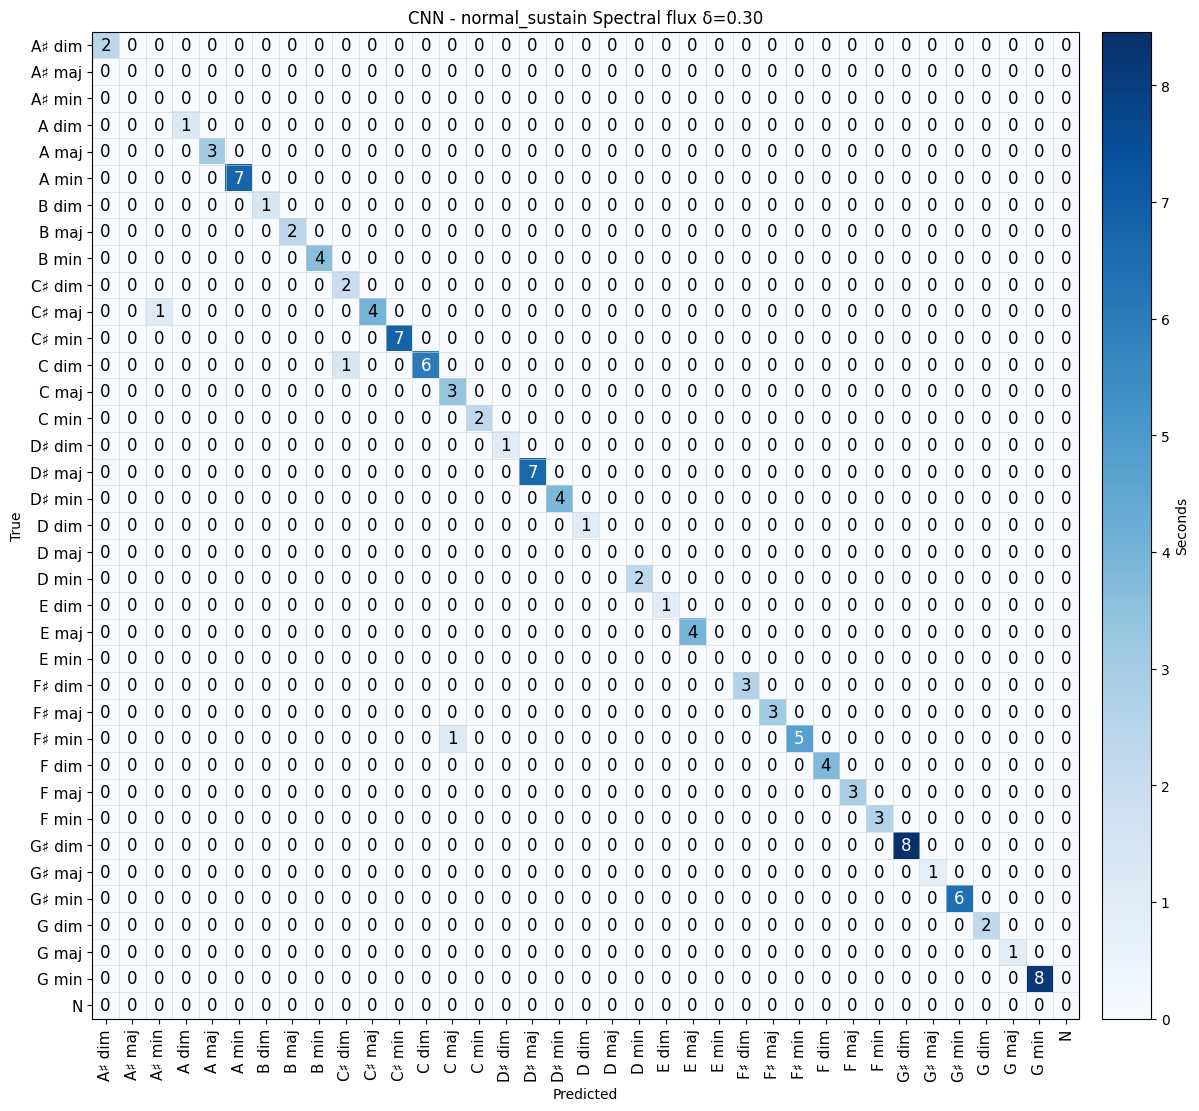

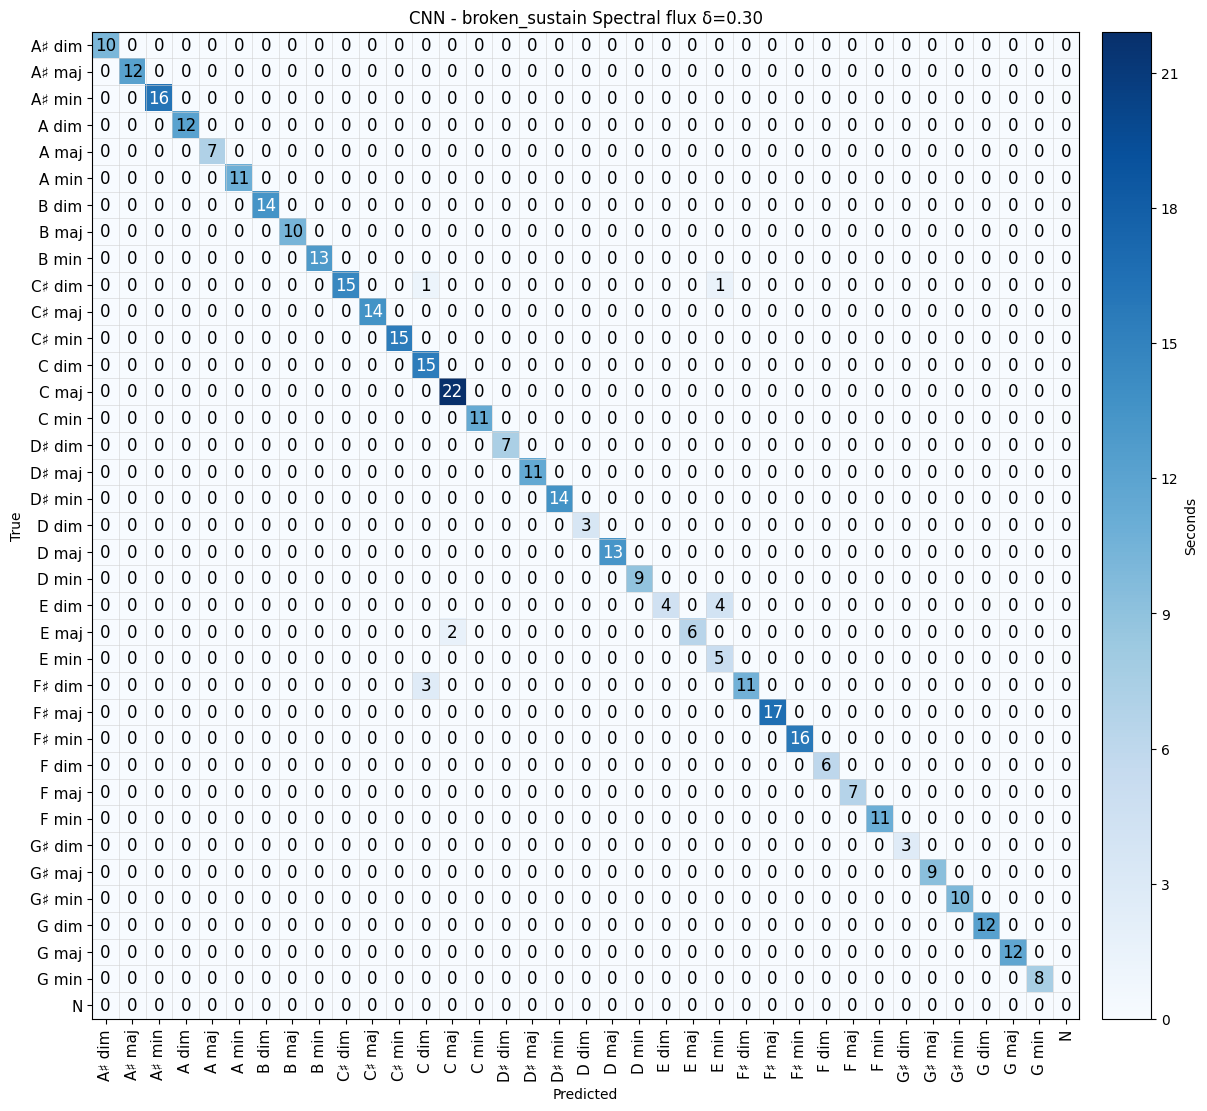

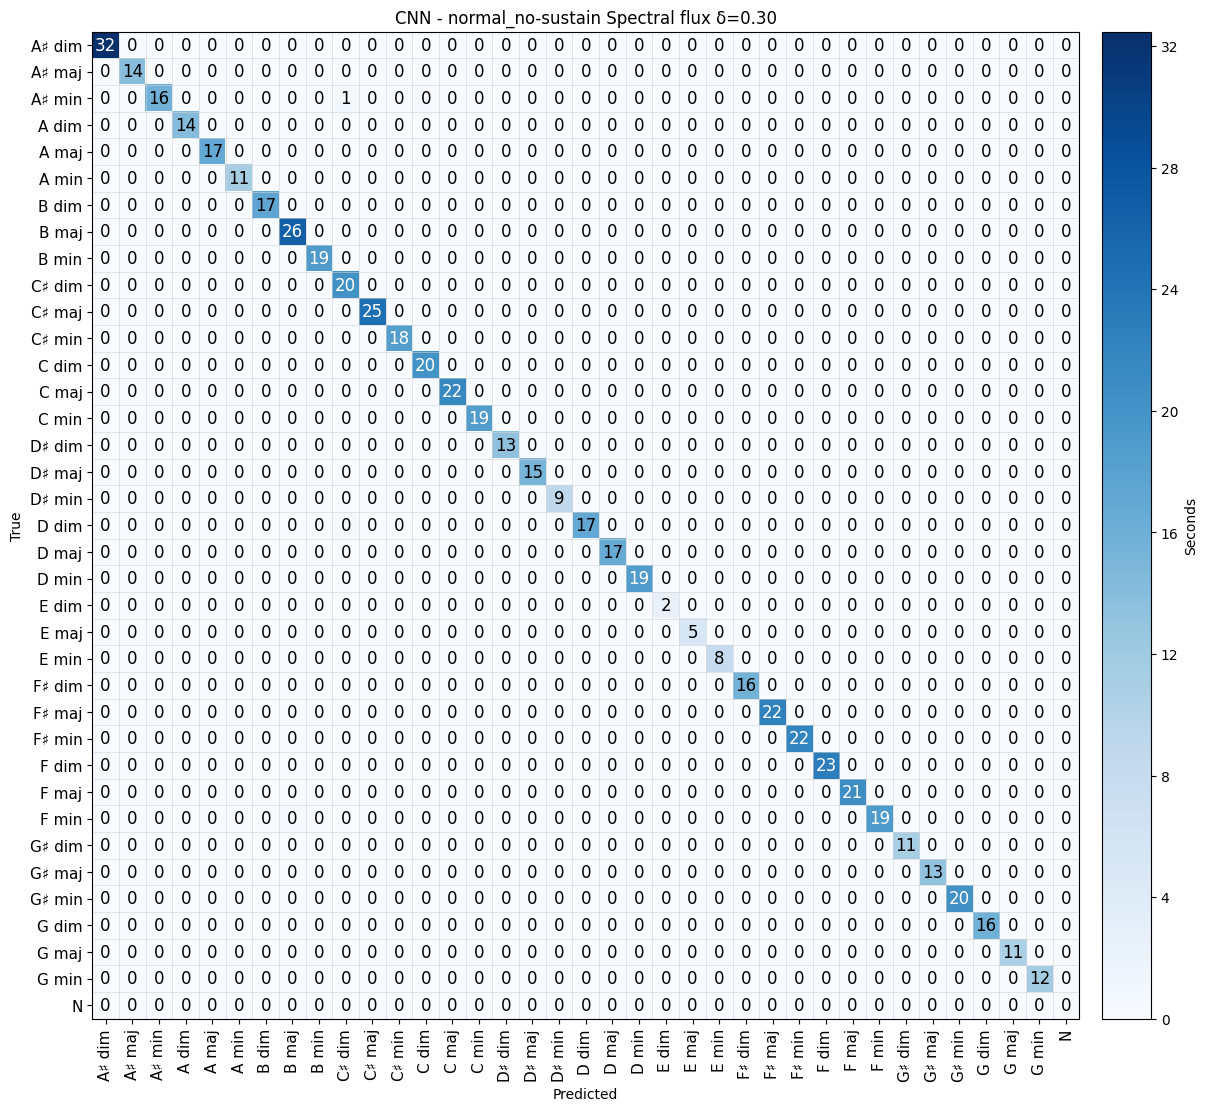

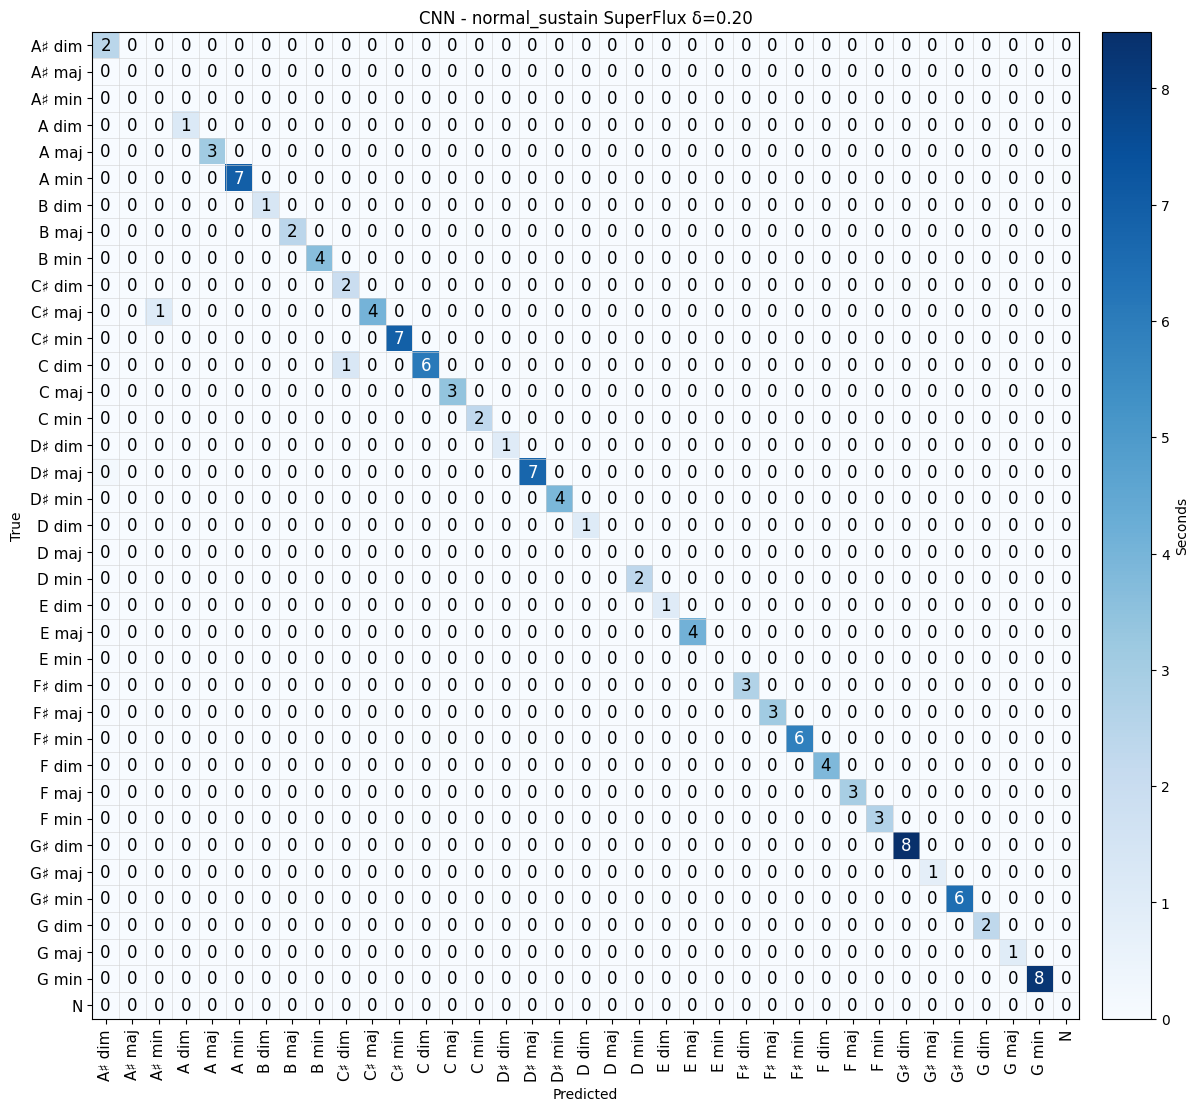

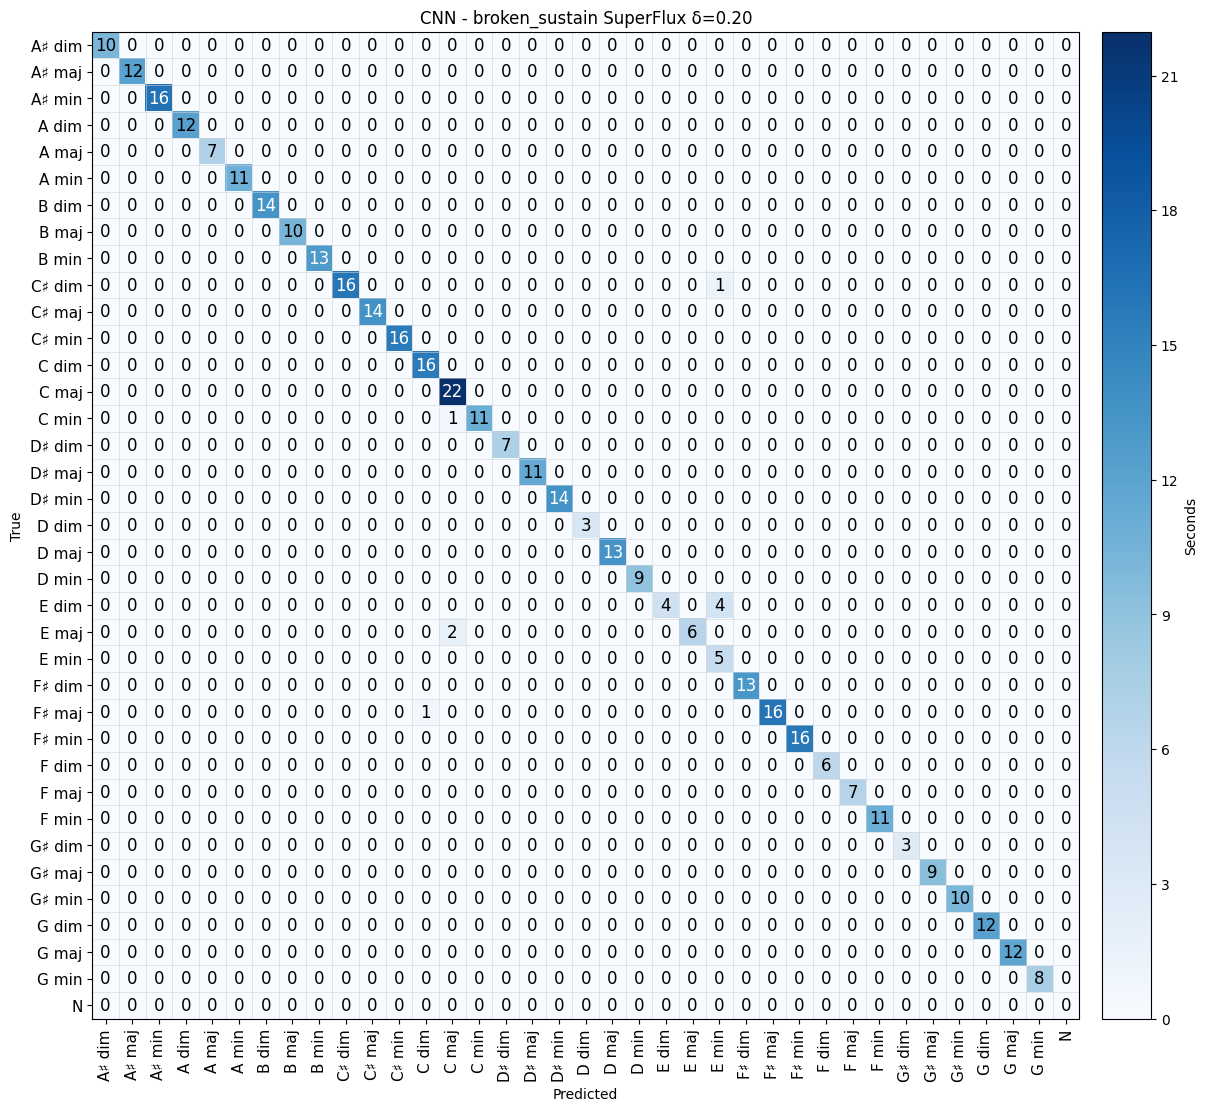

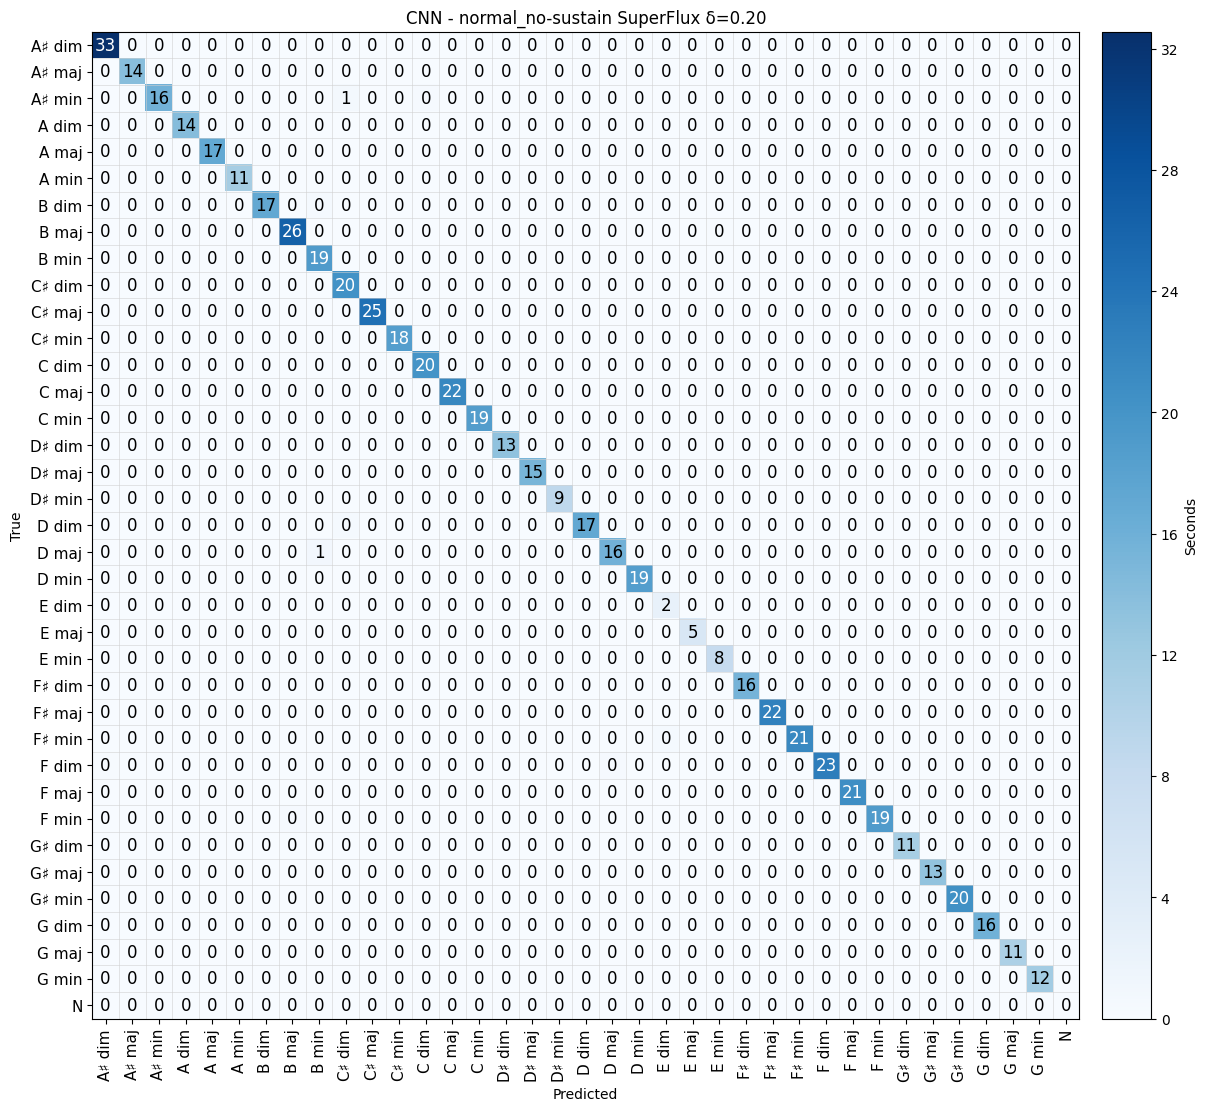

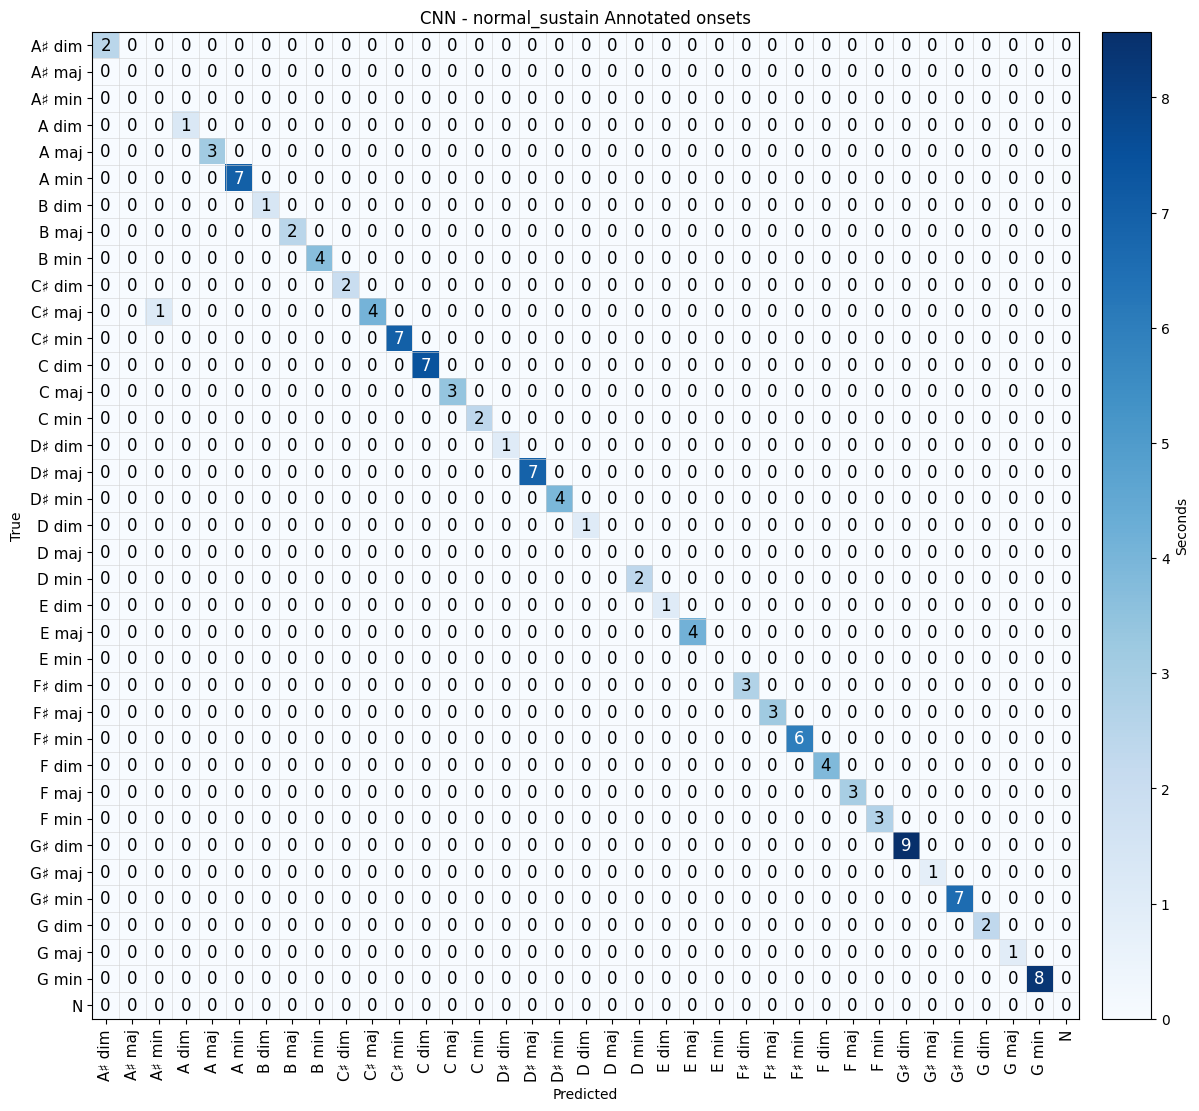

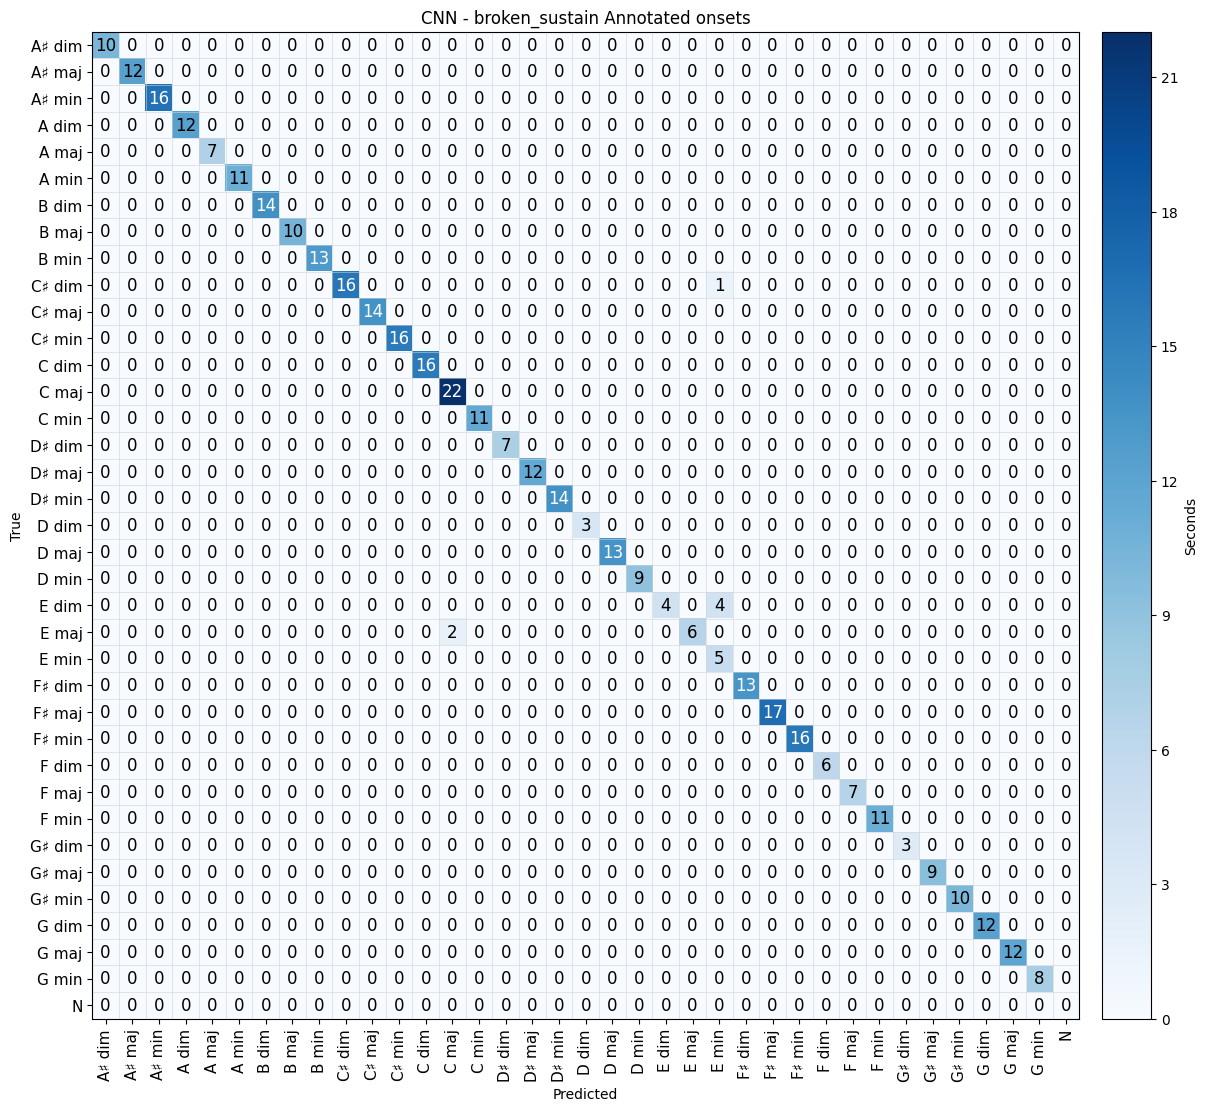

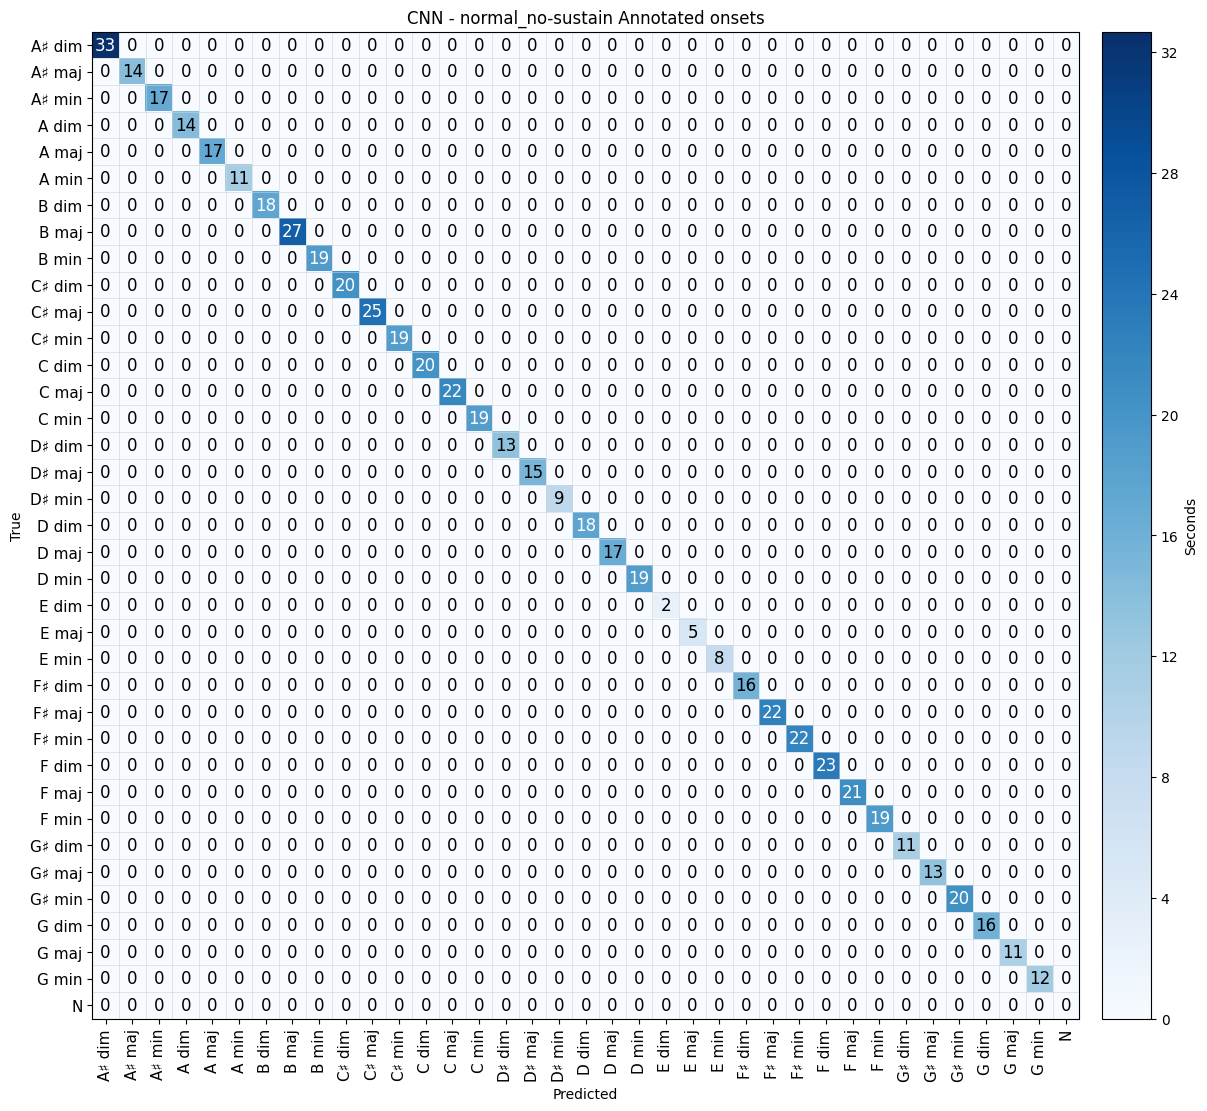

In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

CM_LABELS = [to_mir_eval(name) for name in MODEL_LABELS]
if mir_eval.chord.NO_CHORD not in CM_LABELS:
    CM_LABELS = CM_LABELS + [mir_eval.chord.NO_CHORD]
CM_TICKS = [pretty_mir(name) for name in CM_LABELS]


def duration_cm(ref, est, dur) -> np.ndarray:
    mat = confusion_matrix(ref, est, labels=CM_LABELS, sample_weight=dur)
    return np.asarray(mat, dtype=float)


def draw_cm(ax, mat: np.ndarray, labels: list[str]):
    vmax = max(float(mat.max()), 1.0)
    im = ax.imshow(mat, cmap="Blues", interpolation="nearest", vmin=0, vmax=vmax)
    n = len(labels)
    ax.set_xticks(np.arange(n), labels, rotation=90, fontsize=11)
    ax.set_yticks(np.arange(n), labels, fontsize=11)
    ax.set_xticks(np.arange(n) - 0.5, minor=True)
    ax.set_yticks(np.arange(n) - 0.5, minor=True)
    ax.grid(which="minor", color="0.82", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    thresh = 0.55 * vmax
    for i in range(n):
        for j in range(n):
            val = int(round(mat[i, j]))
            ax.text(
                j, i, str(val),
                ha="center", va="center", fontsize=12,
                color="white" if val >= thresh else "black",
            )
    return im


for detector in DETECTORS:
    for dataset in DATASETS:
        block = runs[detector]["by_dataset"][dataset]
        mat = duration_cm(block["ref"], block["est"], block["dur"])
        pd.DataFrame(mat, index=CM_TICKS, columns=CM_TICKS).to_csv(
            OUT / f"cm_{detector}_{dataset}.csv"
        )
        fig, ax = plt.subplots(figsize=(12.4, 11.0), layout="constrained")
        im = draw_cm(ax, mat, CM_TICKS)
        ax.set_title(f"CNN - {dataset} {DETECTOR_TITLE[detector]}")
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Seconds")
        cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        plt.show()


## Overall

In [7]:
if "per_file" not in globals():
    per_file = pd.read_csv(OUT / "classify_per_file.csv")


def overall_row(df: pd.DataFrame) -> pd.Series:
    w = df["duration"].to_numpy(dtype=float)
    row = {col: float(np.average(df[col].to_numpy(dtype=float), weights=w)) for col in SCORE_COLS}
    row["duration"] = float(w.sum())
    row["n_onsets"] = int(df["n_onsets"].sum())
    row["n_segments"] = int(df["n_segments"].sum())
    row["n_truncated"] = int(df["n_truncated"].sum())
    row["mean_window_frames"] = float(
        np.average(df["mean_window_frames"].to_numpy(dtype=float), weights=w)
    )
    return pd.Series(row)


overall_rows = []
for detector, grp in per_file.groupby("detector", sort=False):
    row = overall_row(grp)
    row["detector"] = detector
    overall_rows.append(row)

overall_table = (
    pd.DataFrame(overall_rows)
    .set_index("detector")
    .reindex(DETECTORS)
    .reset_index()
)
overall_table.to_csv(OUT / "classify_overall.csv", index=False)

display(Markdown(
    "**Overall** — all three sets pooled. Scores are duration-weighted; "
    "counts are sums."
))
display(overall_table[["detector", *SCORE_COLS]].round(4))
display(overall_table[
    ["detector", "duration", "n_onsets", "n_segments", "n_truncated", "mean_window_frames"]
].round(1))


**Overall** — all three sets pooled. Scores are duration-weighted; counts are sums.

,detector,root,thirds,triads,majmin,mirex,underseg,overseg,seg
0,spectral-flux,0.9770,0.9766,0.9730,0.9816,0.9730,0.7071,0.9885,0.7071
1,superflux,0.9830,0.9822,0.9782,0.9828,0.9782,0.7154,0.9955,0.7154
2,annotated,0.9926,0.9925,0.9888,0.9929,0.9888,0.7154,0.9985,0.7154


,detector,duration,n_onsets,n_segments,n_truncated,mean_window_frames
0,spectral-flux,1138.7,620.0,620.0,377.0,159.5
1,superflux,1138.7,628.0,628.0,387.0,158.4
2,annotated,1138.7,620.0,620.0,377.0,160.0


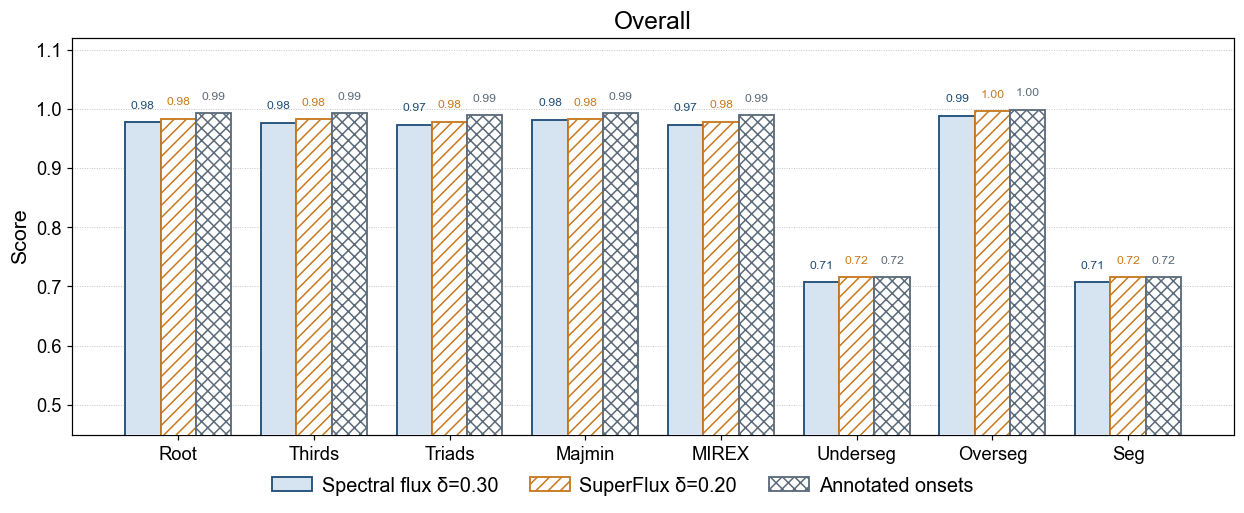

In [8]:
import matplotlib.pyplot as plt

NAVY = "#1f4e79"
ACCENT = "#c8791e"
FILL = "#d6e3f0"
SLATE = "#5c6b7a"
bar_kw = dict(linewidth=1.2, zorder=3)
width = 0.26

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.frameon": False,
    "figure.dpi": 110,
})

SCORE_LABEL = {
    "root": "Root",
    "thirds": "Thirds",
    "triads": "Triads",
    "majmin": "Majmin",
    "mirex": "MIREX",
    "underseg": "Underseg",
    "overseg": "Overseg",
    "seg": "Seg",
}
BAR_STYLE = {
    "spectral-flux": dict(facecolor=FILL, edgecolor=NAVY, hatch=""),
    "superflux": dict(facecolor="white", edgecolor=ACCENT, hatch="///"),
    "annotated": dict(facecolor="white", edgecolor=SLATE, hatch="xxx"),
}
BAR_COLOR = {"spectral-flux": NAVY, "superflux": ACCENT, "annotated": SLATE}
labels = [SCORE_LABEL[c] for c in SCORE_COLS]
by_det = overall_table.set_index("detector")
x = np.arange(len(SCORE_COLS))
offsets = np.linspace(-(len(DETECTORS) - 1) / 2, (len(DETECTORS) - 1) / 2, len(DETECTORS)) * width

fig, ax = plt.subplots(figsize=(11.2, 4.6), layout="constrained")
for det, off in zip(DETECTORS, offsets):
    vals = by_det.loc[det, SCORE_COLS].to_numpy(dtype=float)
    ax.bar(x + off, vals, width, **BAR_STYLE[det], **bar_kw)
    for xi, v in zip(x, vals):
        ax.text(
            xi + off, v + 0.02, f"{v:.2f}",
            ha="center", va="bottom", fontsize=8, color=BAR_COLOR[det],
        )
ax.set_xticks(x, labels)
ax.set_ylabel("Score")
ax.set_ylim(0.45, 1.12)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
ax.set_title("Overall")
fig.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, linewidth=1.2, **BAR_STYLE[det])
        for det in DETECTORS
    ],
    labels=[DETECTOR_TITLE[det] for det in DETECTORS],
    loc="outside lower center", ncol=3, frameon=False,
    columnspacing=1.6, handletextpad=0.5,
)
plt.show()


### Combined confusion

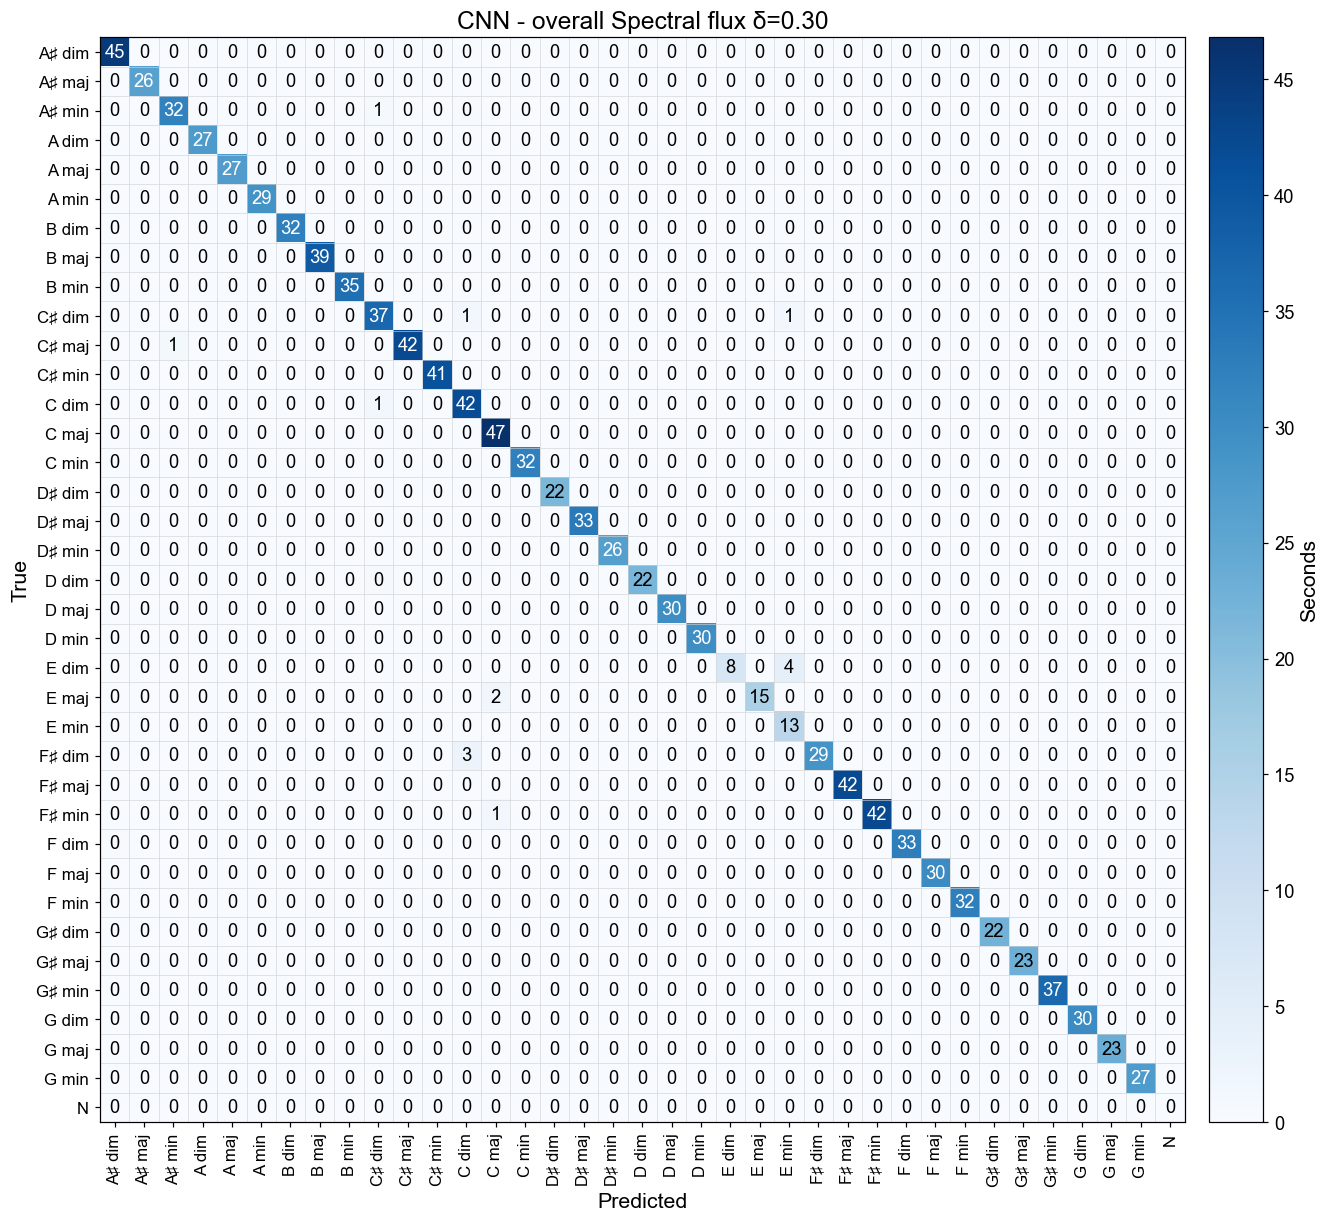

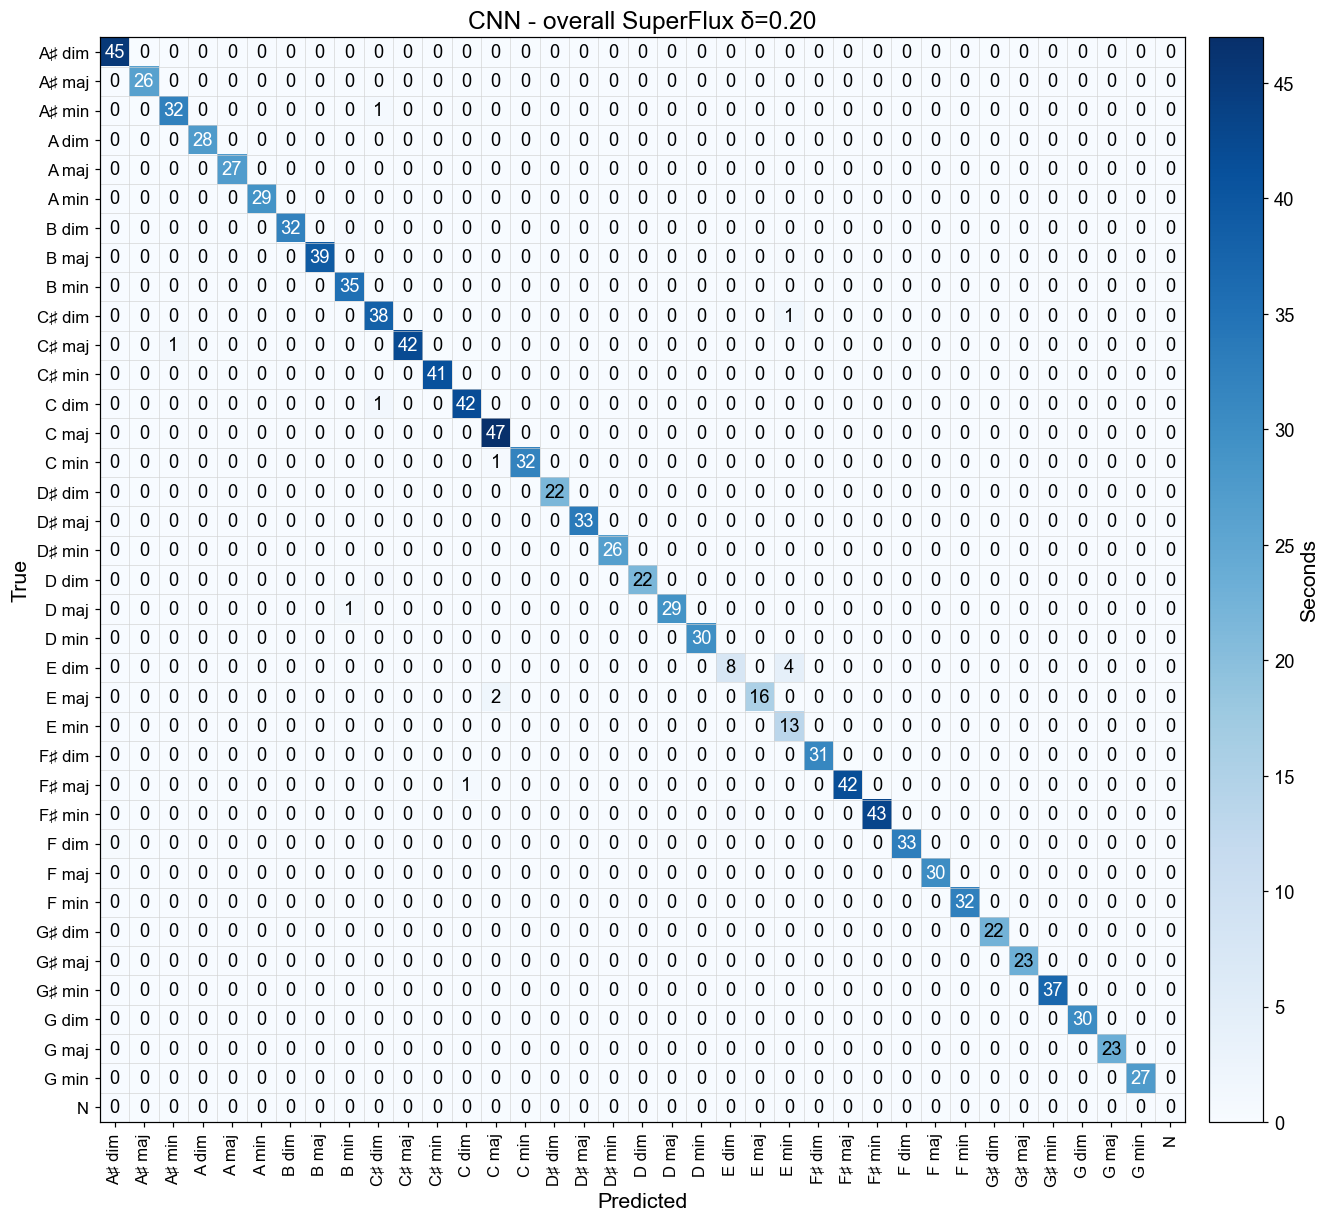

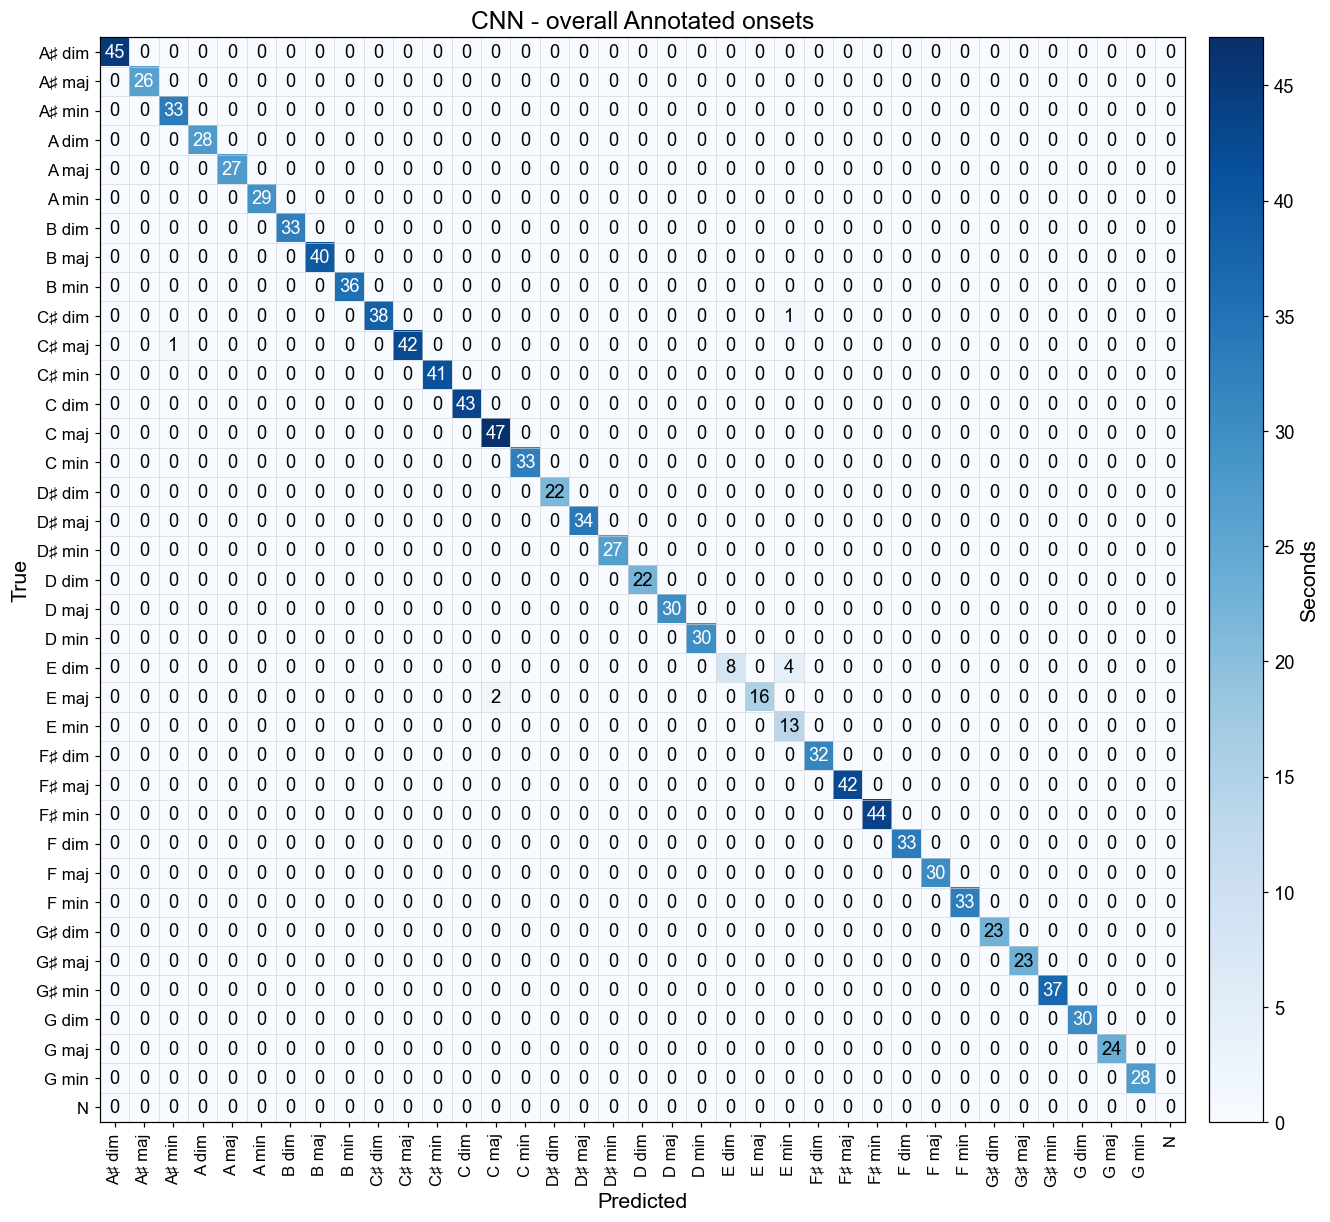

In [9]:
from matplotlib.ticker import MaxNLocator


def draw_cm(ax, mat: np.ndarray, labels: list[str]):
    vmax = max(float(mat.max()), 1.0)
    im = ax.imshow(mat, cmap="Blues", interpolation="nearest", vmin=0, vmax=vmax)
    n = len(labels)
    ax.set_xticks(np.arange(n), labels, rotation=90, fontsize=11)
    ax.set_yticks(np.arange(n), labels, fontsize=11)
    ax.set_xticks(np.arange(n) - 0.5, minor=True)
    ax.set_yticks(np.arange(n) - 0.5, minor=True)
    ax.grid(which="minor", color="0.82", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    thresh = 0.55 * vmax
    for i in range(n):
        for j in range(n):
            val = int(round(mat[i, j]))
            ax.text(
                j, i, str(val),
                ha="center", va="center", fontsize=12,
                color="white" if val >= thresh else "black",
            )
    return im


def load_pooled_cm(detector: str) -> pd.DataFrame:
    parts = [
        pd.read_csv(OUT / f"cm_{detector}_{dataset}.csv", index_col=0)
        for dataset in DATASETS
    ]
    out = parts[0].copy()
    for part in parts[1:]:
        out = out.add(part, fill_value=0)
    return out


for detector in DETECTORS:
    cm_df = load_pooled_cm(detector)
    cm_df.to_csv(OUT / f"cm_{detector}_overall.csv")
    mat = cm_df.to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(12.4, 11.0), layout="constrained")
    im = draw_cm(ax, mat, list(cm_df.index))
    ax.set_title(f"CNN - overall {DETECTOR_TITLE[detector]}")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Seconds")
    cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()


## Chord pairs

Consecutive annotated chords (octave stripped). The second chord is counted as correct if the duration-weighted majority CNN label on its annotated interval matches. All three sets are pooled. Spectral flux δ=0.30, SuperFlux δ=0.20, and annotated onsets.

In [10]:
ROOTS = ["C", "C♯", "D", "D♯", "E", "F", "F♯", "G", "G♯", "A", "A♯", "B"]
QUALS = ["maj", "min", "dim"]
CLASS_ORDER = [f"{root} {qual}" for root in ROOTS for qual in QUALS]


def majority_on_interval(est_i: np.ndarray, est_y: list[str], t0: float, t1: float) -> str:
    weights: dict[str, float] = {}
    for (a, b), lab in zip(np.atleast_2d(est_i), est_y):
        overlap = max(0.0, min(float(b), t1) - max(float(a), t0))
        if overlap > 0:
            weights[lab] = weights.get(lab, 0.0) + overlap
    if not weights:
        return mir_eval.chord.NO_CHORD
    return max(weights, key=weights.get)


def split_pretty(label: str) -> tuple[str, str]:
    parts = str(label).split()
    if len(parts) >= 2:
        return parts[0], parts[-1]
    return label, ""


pair_rows = []
for detector in DETECTORS:
    for dataset in DATASETS:
        z = np.load(VALID / f"{dataset}.npz", allow_pickle=True)
        features, annotations = list(z["features"]), list(z["annotations"])
        for sample_index, (cqt, anns) in enumerate(zip(features, annotations)):
            onsets = detect_onsets(cqt, anns, detector)
            windows = windows_from_onsets(cqt, onsets)
            pred = predict_windows(windows)
            est_i = np.array([[w["start"], w["end"]] for w in windows], dtype=float)
            for k in range(len(anns) - 1):
                ev = anns[k + 1]
                t0, t1 = float(ev["start"]), float(ev["end"])
                true = to_mir_eval(ev["chord"])
                est_lab = majority_on_interval(est_i, pred, t0, t1)
                from_lab = pretty_mir(to_mir_eval(anns[k]["chord"]))
                to_lab = pretty_mir(true)
                from_root, from_qual = split_pretty(from_lab)
                to_root, to_qual = split_pretty(to_lab)
                pair_rows.append(
                    {
                        "detector": detector,
                        "dataset": dataset,
                        "from": from_lab,
                        "to": to_lab,
                        "from_root": from_root,
                        "to_root": to_root,
                        "from_qual": from_qual,
                        "to_qual": to_qual,
                        "same_root": from_root == to_root,
                        "true": pretty_mir(true),
                        "pred": pretty_mir(est_lab),
                        "correct": int(est_lab == true),
                    }
                )

classify_pairs = pd.DataFrame(pair_rows)
classify_pairs.to_csv(OUT / "classify_pairs.csv", index=False)
display(Markdown(
    f"Scored **{len(classify_pairs):,}** transitions "
    f"({classify_pairs.detector.nunique()} detectors × "
    f"{int(len(classify_pairs) / classify_pairs.detector.nunique()):,} pairs)."
))


Scored **1,674** transitions (3 detectors × 558 pairs).

In [11]:
def summarize_pairs(df: pd.DataFrame, keys: list[str]) -> pd.DataFrame:
    out = (
        df.groupby(keys, as_index=False)
        .agg(n=("correct", "size"), correct=("correct", "sum"))
    )
    out["missed"] = out.n - out.correct
    out["recall"] = np.where(out.n > 0, out.correct / out.n, np.nan)
    return out.sort_values(
        ["missed", "n", *keys], ascending=[False, False] + [True] * len(keys)
    ).reset_index(drop=True)


def show_pair_block(title: str, df: pd.DataFrame):
    display(Markdown(title))
    display(df.round(3))


by_detector = {det: classify_pairs.loc[classify_pairs.detector == det] for det in DETECTORS}

headline = []
for det, df in by_detector.items():
    headline.append({
        "detector": det,
        "n": int(df.shape[0]),
        "correct": int(df.correct.sum()),
        "missed": int((1 - df.correct).sum()),
        "recall": float(df.correct.mean()),
    })
    chord_tab = summarize_pairs(df, ["from", "to"])
    chord_tab.to_csv(OUT / f"classify_pairs_{det}.csv", index=False)
show_pair_block("**Chord-pair classification** — all three sets", pd.DataFrame(headline))

qual_wide = None
for det, df in by_detector.items():
    q = summarize_pairs(df, ["from_qual", "to_qual"]).add_prefix(f"{det}_")
    q = q.rename(columns={
        f"{det}_from_qual": "from_qual",
        f"{det}_to_qual": "to_qual",
    })
    qual_wide = q if qual_wide is None else qual_wide.merge(
        q, on=["from_qual", "to_qual"], how="outer"
    )
qual_cols = ["from_qual", "to_qual"]
for det in DETECTORS:
    qual_cols.extend([f"{det}_n", f"{det}_correct", f"{det}_missed", f"{det}_recall"])
show_pair_block("**Quality pairs**", qual_wide[qual_cols])

root_wide = None
for det, df in by_detector.items():
    r = summarize_pairs(df, ["same_root"]).add_prefix(f"{det}_")
    r = r.rename(columns={f"{det}_same_root": "same_root"})
    root_wide = r if root_wide is None else root_wide.merge(r, on="same_root", how="outer")
root_cols = ["same_root"]
for det in DETECTORS:
    root_cols.extend([f"{det}_n", f"{det}_correct", f"{det}_missed", f"{det}_recall"])
show_pair_block("**Same root vs different root**", root_wide[root_cols])

focus = by_detector["superflux"]
flux_focus = by_detector["spectral-flux"]
ann_focus = by_detector["annotated"]
chord_pairs = summarize_pairs(focus, ["from", "to"])
flux_pairs = summarize_pairs(flux_focus, ["from", "to"])
show_pair_block("**Missed chord pairs — SuperFlux**", chord_pairs.loc[chord_pairs.missed > 0])
show_pair_block("**Missed chord pairs — Spectral flux**", flux_pairs.loc[flux_pairs.missed > 0])
show_pair_block(
    "**C maj → C dim**",
    pd.concat(
        [
            summarize_pairs(df, ["from", "to"]).assign(detector=det)
            for det, df in by_detector.items()
        ],
        ignore_index=True,
    ).loc[lambda d: (d["from"] == "C maj") & (d["to"] == "C dim")],
)


**Chord-pair classification** — all three sets

,detector,n,correct,missed,recall
0,spectral-flux,558,549,9,0.984
1,superflux,558,552,6,0.989
2,annotated,558,553,5,0.991


**Quality pairs**

,from_qual,to_qual,spectral-flux_n,spectral-flux_correct,spectral-flux_missed,spectral-flux_recall,superflux_n,superflux_correct,superflux_missed,superflux_recall,annotated_n,annotated_correct,annotated_missed,annotated_recall
0,dim,dim,64,60,4,0.938,64,62,2,0.969,64,63,1,0.984
1,dim,maj,61,61,0,1.000,61,61,0,1.000,61,61,0,1.000
2,dim,min,56,56,0,1.000,56,56,0,1.000,56,56,0,1.000
3,maj,dim,62,61,1,0.984,62,61,1,0.984,62,61,1,0.984
4,maj,maj,65,64,1,0.985,65,64,1,0.985,65,64,1,0.985
5,maj,min,61,60,1,0.984,61,61,0,1.000,61,61,0,1.000
6,min,dim,53,52,1,0.981,53,52,1,0.981,53,52,1,0.981
7,min,maj,67,66,1,0.985,67,66,1,0.985,67,66,1,0.985
8,min,min,69,69,0,1.000,69,69,0,1.000,69,69,0,1.000


**Same root vs different root**

...

,from,to,n,correct,missed,recall
0,C♯ dim,C dim,2,1,1,0.5
1,C♯ min,E maj,2,1,1,0.5
2,C♯ maj,C♯ dim,1,0,1,0.0
3,C♯ min,E dim,1,0,1,0.0
4,F♯ maj,C♯ maj,1,0,1,0.0
5,G dim,E dim,1,0,1,0.0


**Missed chord pairs — Spectral flux**

,from,to,n,correct,missed,recall
0,C maj,F♯ min,2,1,1,0.5
1,C♯ dim,C dim,2,1,1,0.5
2,C♯ dim,C♯ dim,2,1,1,0.5
3,C♯ min,E maj,2,1,1,0.5
4,C♯ dim,F♯ dim,1,0,1,0.0
5,C♯ maj,C♯ dim,1,0,1,0.0
6,C♯ min,E dim,1,0,1,0.0
7,F♯ maj,C♯ maj,1,0,1,0.0
8,G dim,E dim,1,0,1,0.0


**C maj → C dim**

,from,to,n,correct,missed,recall,detector
205,C maj,C dim,1,1,0,1.0,spectral-flux
660,C maj,C dim,1,1,0,1.0,superflux
1116,C maj,C dim,1,1,0,1.0,annotated


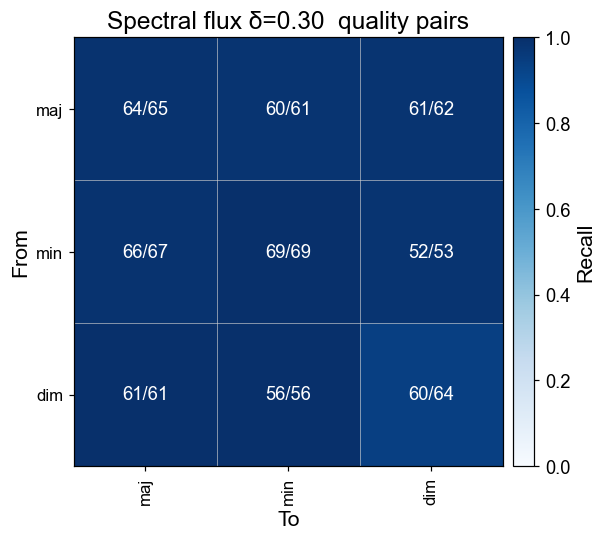

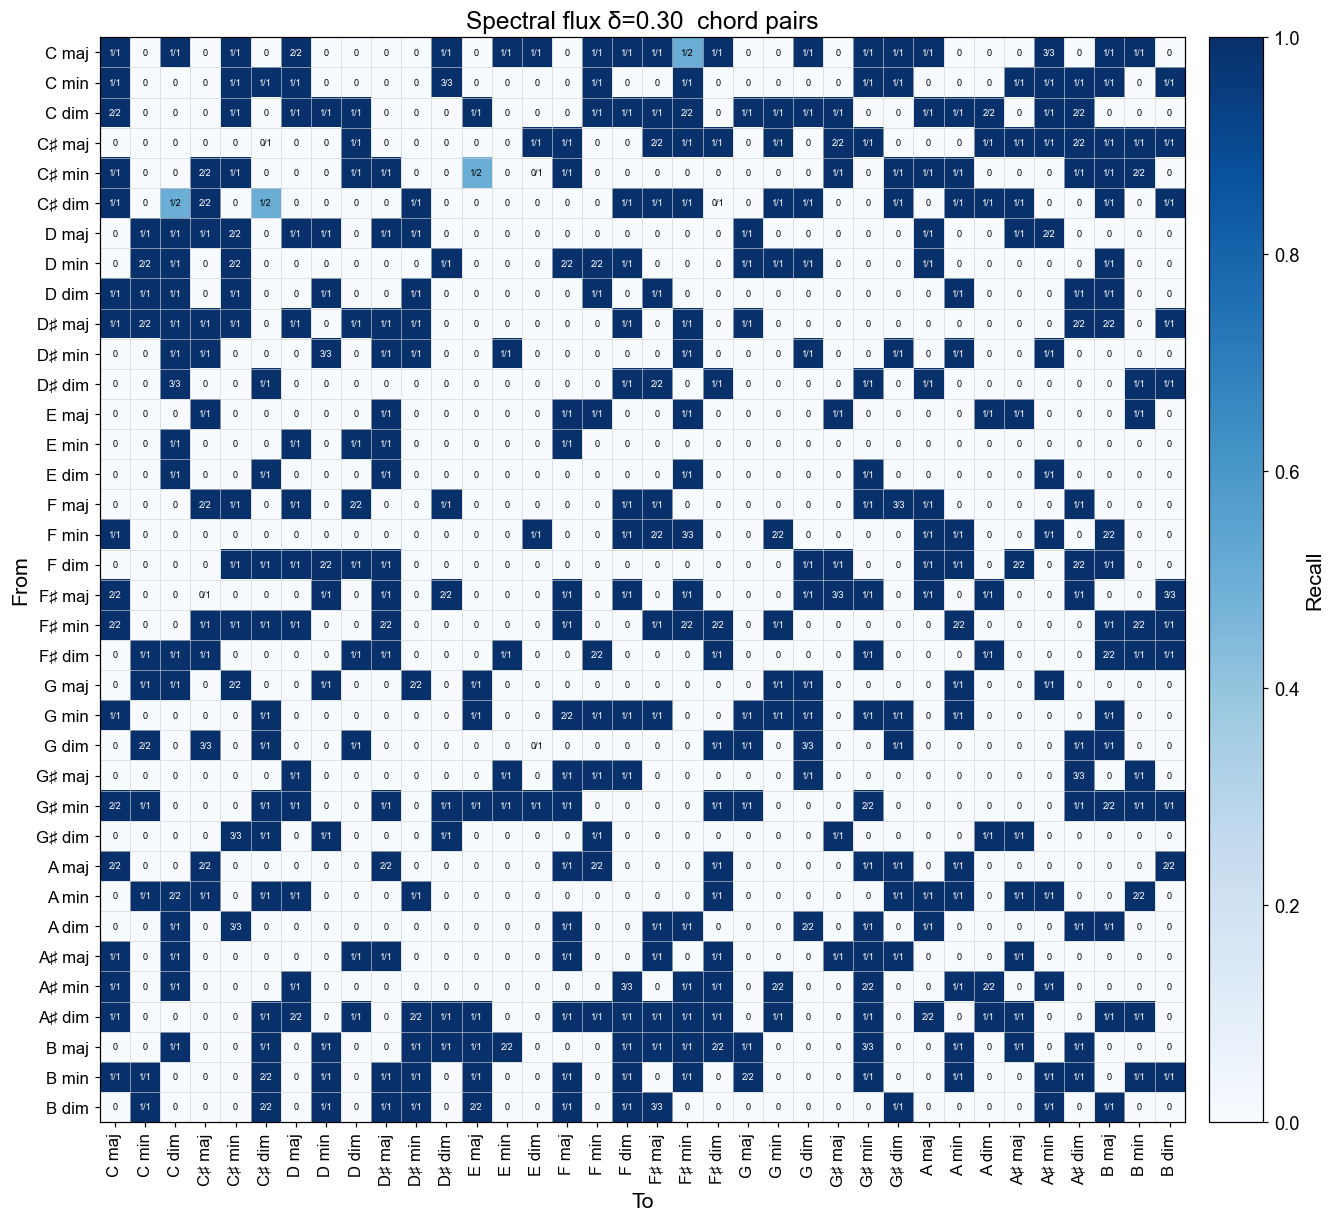

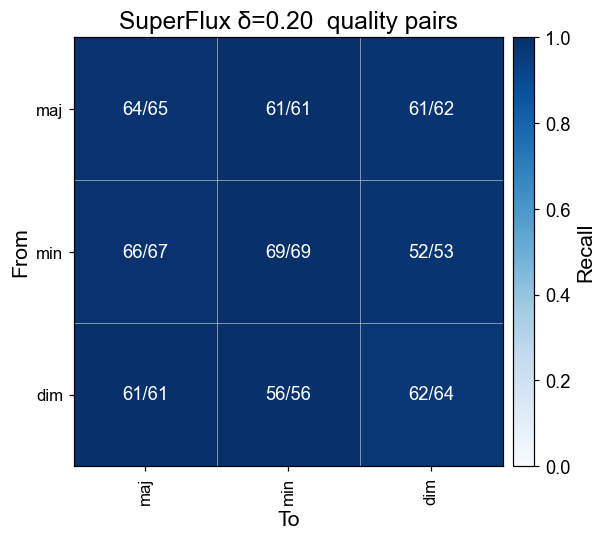

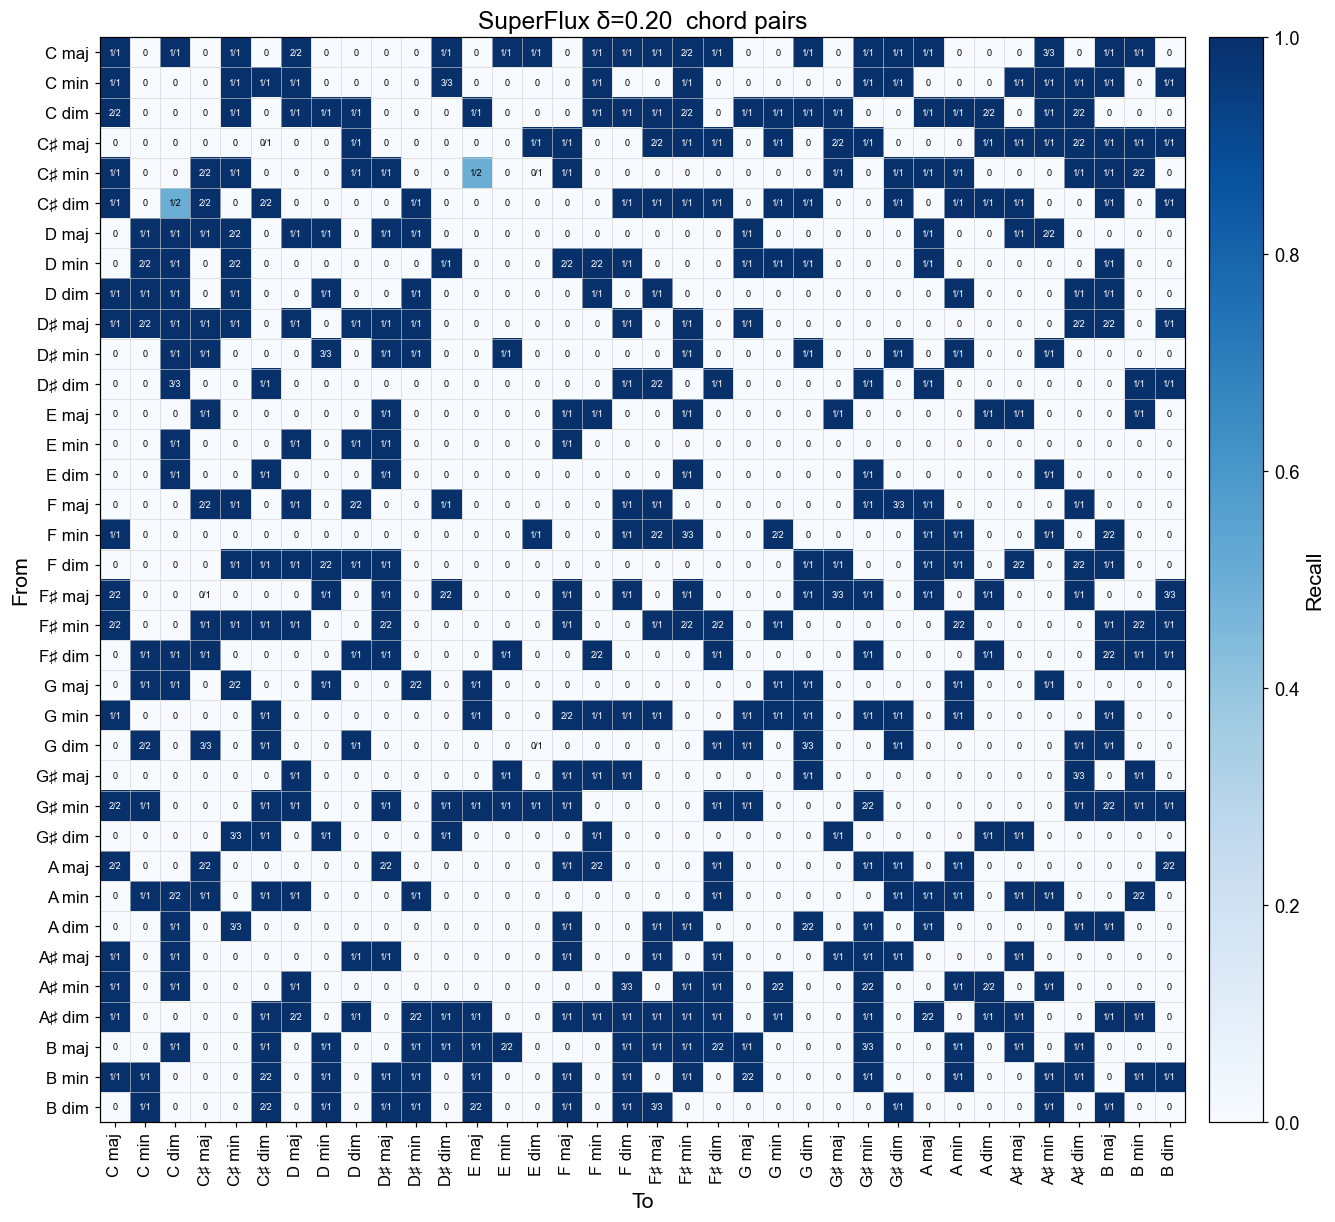

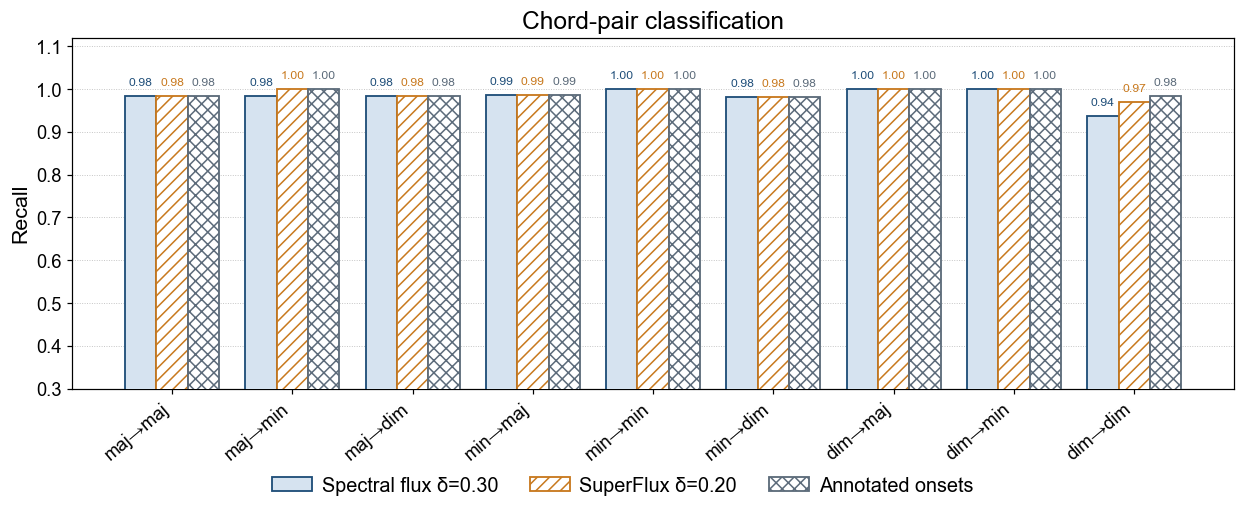

In [12]:
import matplotlib.pyplot as plt

NAVY = "#1f4e79"
ACCENT = "#c8791e"
FILL = "#d6e3f0"
SLATE = "#5c6b7a"
BAR_STYLE = {
    "spectral-flux": dict(facecolor=FILL, edgecolor=NAVY, hatch=""),
    "superflux": dict(facecolor="white", edgecolor=ACCENT, hatch="///"),
    "annotated": dict(facecolor="white", edgecolor=SLATE, hatch="xxx"),
}
BAR_COLOR = {"spectral-flux": NAVY, "superflux": ACCENT, "annotated": SLATE}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.frameon": False,
    "figure.dpi": 110,
})


def counts_matrix(df: pd.DataFrame, row_key: str, col_key: str, rows: list[str], cols: list[str]):
    n = (
        df.groupby([row_key, col_key])
        .size()
        .unstack(col_key)
        .reindex(index=rows, columns=cols)
        .fillna(0)
        .astype(int)
    )
    hit = (
        df.groupby([row_key, col_key])["correct"]
        .sum()
        .unstack(col_key)
        .reindex(index=rows, columns=cols)
        .fillna(0)
        .astype(int)
    )
    return hit, n


def draw_count_matrix(ax, hit: pd.DataFrame, n: pd.DataFrame, title: str, cell_fs: int):
    recall = np.divide(
        hit.to_numpy(dtype=float),
        n.to_numpy(dtype=float),
        out=np.zeros(hit.shape, dtype=float),
        where=n.to_numpy() > 0,
    )
    im = ax.imshow(recall, cmap="Blues", vmin=0.0, vmax=1.0, interpolation="nearest")
    labels_r = list(hit.index)
    labels_c = list(hit.columns)
    nr, nc = hit.shape
    ax.set_xticks(np.arange(nc), labels_c, rotation=90, fontsize=11)
    ax.set_yticks(np.arange(nr), labels_r, fontsize=11)
    ax.set_xticks(np.arange(nc) - 0.5, minor=True)
    ax.set_yticks(np.arange(nr) - 0.5, minor=True)
    ax.grid(which="minor", color="0.82", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_xlabel("To")
    ax.set_ylabel("From")
    ax.set_title(title)
    for i in range(nr):
        for j in range(nc):
            nn = int(n.iloc[i, j])
            hh = int(hit.iloc[i, j])
            text = f"{hh}/{nn}" if nn else "0"
            ax.text(
                j, i, text,
                ha="center", va="center", fontsize=cell_fs,
                color="white" if nn and recall[i, j] >= 0.55 else "black",
            )
    return im


for det in ["spectral-flux", "superflux"]:
    q_hit, q_n = counts_matrix(by_detector[det], "from_qual", "to_qual", QUALS, QUALS)
    fig, ax = plt.subplots(figsize=(5.6, 4.8), layout="constrained")
    im = draw_count_matrix(ax, q_hit, q_n, f"{DETECTOR_TITLE[det]}  quality pairs", 12)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Recall")
    plt.show()

    c_hit, c_n = counts_matrix(by_detector[det], "from", "to", CLASS_ORDER, CLASS_ORDER)
    fig, ax = plt.subplots(figsize=(12.4, 11.0), layout="constrained")
    im = draw_count_matrix(ax, c_hit, c_n, f"{DETECTOR_TITLE[det]}  chord pairs", 6)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Recall")
    plt.show()

bar_kw = dict(linewidth=1.2, zorder=3)
width = 0.26
qual_keys = [f"{a}→{b}" for a in QUALS for b in QUALS]
x = np.arange(len(qual_keys))
offsets = np.linspace(-(len(DETECTORS) - 1) / 2, (len(DETECTORS) - 1) / 2, len(DETECTORS)) * width

fig, ax = plt.subplots(figsize=(11.2, 4.6), layout="constrained")
for det, off in zip(DETECTORS, offsets):
    recs = []
    df = by_detector[det]
    for a in QUALS:
        for b in QUALS:
            sub = df.loc[(df.from_qual == a) & (df.to_qual == b), "correct"]
            recs.append(float(sub.mean()) if len(sub) else np.nan)
    ax.bar(x + off, recs, width, **BAR_STYLE[det], **bar_kw)
    for xi, v in zip(x, recs):
        if np.isfinite(v):
            ax.text(
                xi + off, v + 0.02, f"{v:.2f}",
                ha="center", va="bottom", fontsize=8, color=BAR_COLOR[det],
            )
ax.set_xticks(x, qual_keys, rotation=40, ha="right")
ax.set_ylabel("Recall")
ax.set_ylim(0.30, 1.12)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
ax.set_title("Chord-pair classification")
fig.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, linewidth=1.2, **BAR_STYLE[det])
        for det in DETECTORS
    ],
    labels=[DETECTOR_TITLE[det] for det in DETECTORS],
    loc="outside lower center", ncol=3, frameon=False,
    columnspacing=1.6, handletextpad=0.5,
)
plt.show()
